SVM classification accuracy per fold: [0.80612245 0.68041237 0.77319588 0.62886598 0.6185567 ]
Mean accuracy: 0.70 ± 0.08


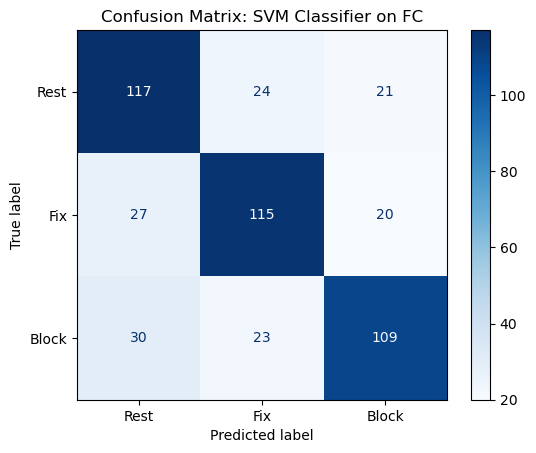

In [3]:
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# FC (shape: subjects, electrodes, electrodes, blocks)
fc_rest_all = np.load("rest_all_fc.npy")
fc_fix_all = np.load("fix_all_fc.npy")
fc_block_all = np.load("block_all_fc.npy")

# Function to vectorize upper triangle of FC matrices
def vectorize_fc(fc_array):  # shape: (subjects, electrodes, electrodes, blocks)
    n_subjects, n_elec, _, n_blocks = fc_array.shape
    iu = np.triu_indices(n_elec, k=1)
    vectors = []
    for subj in range(n_subjects):
        for blk in range(n_blocks):
            fc = fc_array[subj, :, :, blk]
            vec = fc[iu]
            vectors.append(vec)
    return np.array(vectors)

# Vectorize FC data
X_rest = vectorize_fc(fc_rest_all)
X_fix  = vectorize_fc(fc_fix_all)
X_block = vectorize_fc(fc_block_all)

# Create labels
y_rest = np.zeros(len(X_rest))        # label 0
y_fix = np.ones(len(X_fix))           # label 1
y_block = np.full(len(X_block), 2)    # label 2

# Combine all
X = np.vstack([X_rest, X_fix, X_block])
y = np.concatenate([y_rest, y_fix, y_block])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train SVM with cross-validation
clf = SVC(kernel='linear')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X_scaled, y, cv=cv)

print("SVM classification accuracy per fold:", scores)
print("Mean accuracy: {:.2f} ± {:.2f}".format(np.mean(scores), np.std(scores)))

# Optional: Confusion matrix
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = cross_val_predict(clf, X_scaled, y, cv=cv)
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rest", "Fix", "Block"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: SVM Classifier on FC")
plt.show()


SVM classification accuracy per fold (spec data): [0.58163265 0.55670103 0.54639175 0.56701031 0.64948454]
Mean accuracy: 0.58 ± 0.04


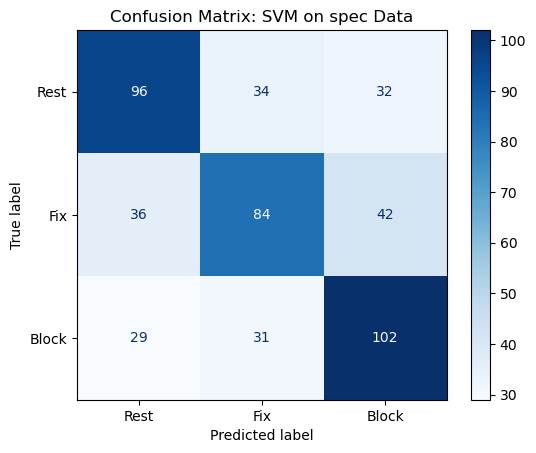

In [6]:
import numpy as np
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

spec_rest_all = np.load("spec_rest_all.npy")  # shape: (subjects, electrodes, blocks)
spec_fix_all = np.load("spec_fix_all.npy")
spec_block_all = np.load("spec_block_all.npy")


# Flatten spec data into shape (samples, features)
def reshape_spec(spec_data):  # shape: (subjects, electrodes, blocks)
    n_subjects, n_elec, n_blocks = spec_data.shape
    data = []
    for subj in range(n_subjects):
        for blk in range(n_blocks):
            vec = spec_data[subj, :, blk]  # 19 features (electrodes)
            data.append(vec)
    return np.array(data)

# Create feature matrix
X_rest = reshape_spec(spec_rest_all)
X_fix = reshape_spec(spec_fix_all)
X_block = reshape_spec(spec_block_all)

X = np.vstack([X_rest, X_fix, X_block])
y = np.array([0]*len(X_rest) + [1]*len(X_fix) + [2]*len(X_block))  # 0=rest, 1=fix, 2=block

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# SVM classifier
clf = SVC(kernel='linear')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X_scaled, y, cv=cv)

print("SVM classification accuracy per fold (spec data):", scores)
print("Mean accuracy: {:.2f} ± {:.2f}".format(np.mean(scores), np.std(scores)))

# Confusion matrix
y_pred = cross_val_predict(clf, X_scaled, y, cv=cv)
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rest", "Fix", "Block"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: SVM on spec Data")
plt.show()


Best parameters from grid search: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validated accuracy: 0.70


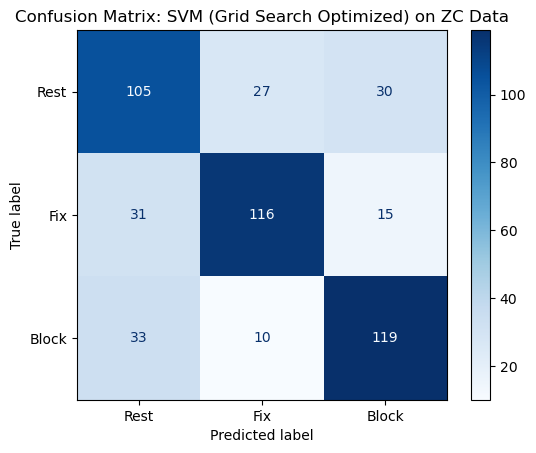

In [7]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load data
auc_rest_all = np.load("zc_rest_all.npy")  # shape: (subjects, electrodes, blocks)
auc_fix_all = np.load("zc_fix_all.npy")
auc_block_all = np.load("zc_block_all.npy")

# Flatten AUC data into shape (samples, features)
def reshape_auc(auc_data):
    n_subjects, n_elec, n_blocks = auc_data.shape
    data = []
    for subj in range(n_subjects):
        for blk in range(n_blocks):
            vec = auc_data[subj, :, blk]  # 19 features (electrodes)
            data.append(vec)
    return np.array(data)

# Create feature matrix
X_rest = reshape_auc(auc_rest_all)
X_fix = reshape_auc(auc_fix_all)
X_block = reshape_auc(auc_block_all)

X = np.vstack([X_rest, X_fix, X_block])
y = np.array([0]*len(X_rest) + [1]*len(X_fix) + [2]*len(X_block))  # 0=rest, 1=fix, 2=block

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define parameter grid for RBF SVM
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

# Perform grid search with cross-validation
grid = GridSearchCV(SVC(), param_grid, cv=cv, scoring='accuracy')
grid.fit(X_scaled, y)

# Report best parameters
print("Best parameters from grid search:", grid.best_params_)
print("Best cross-validated accuracy: {:.2f}".format(grid.best_score_))

# Predict labels using best estimator for confusion matrix
best_clf = grid.best_estimator_
y_pred = cross_val_predict(best_clf, X_scaled, y, cv=cv)

# Compute and plot confusion matrix
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rest", "Fix", "Block"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: SVM (Grid Search Optimized) on ZC Data")
plt.show()


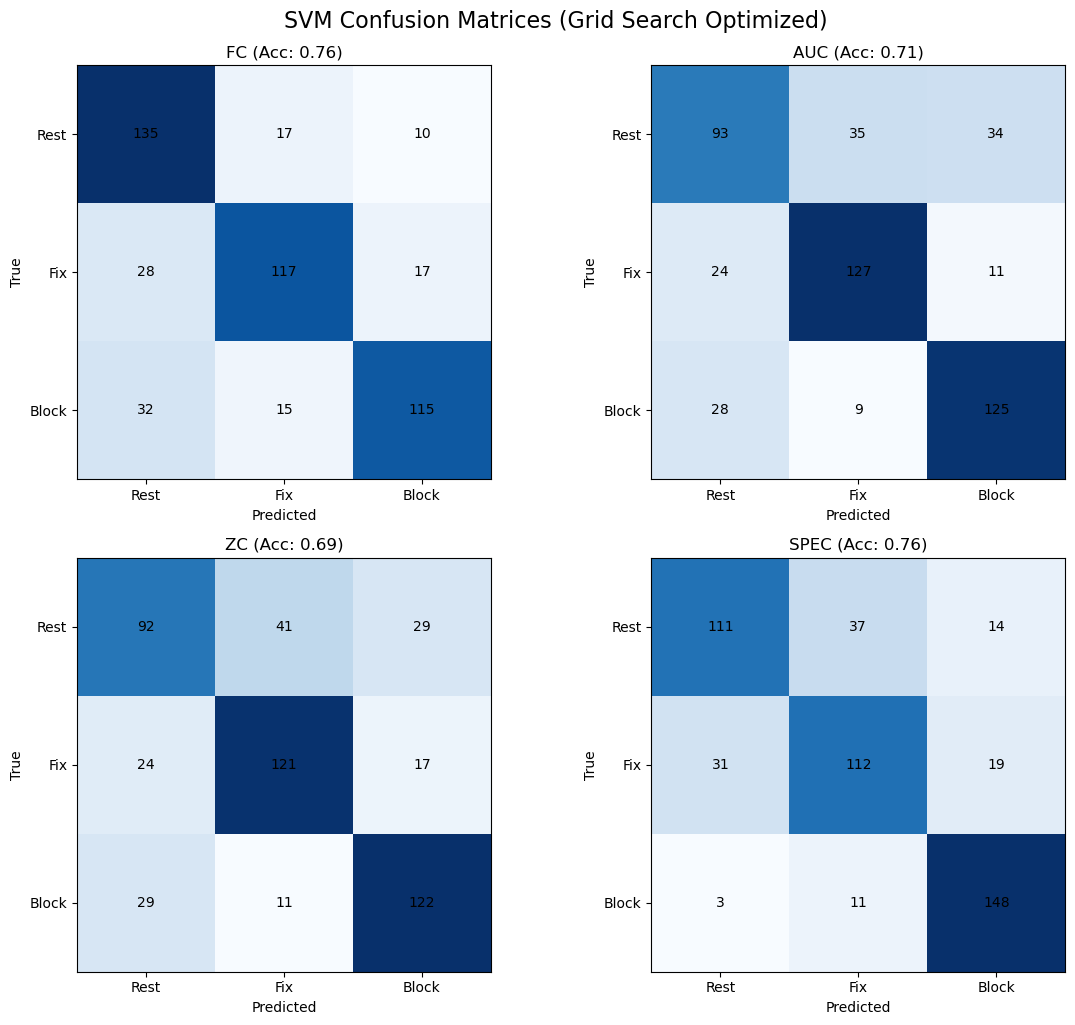

Best SVM Parameters:
FC: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
AUC: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
ZC: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
SPEC: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# ==== Load Data ====

# FC (shape: subjects, electrodes, electrodes, blocks)
fc_rest_all = np.load("rest_all_fc.npy")
fc_fix_all = np.load("fix_all_fc.npy")
fc_block_all = np.load("block_all_fc.npy")

# AUC
auc_rest_all = np.load("auc_rest_all.npy")
auc_fix_all = np.load("auc_fix_all.npy")
auc_block_all = np.load("auc_block_all.npy")

# ZC
zc_rest_all = np.load("zc_rest_all.npy")
zc_fix_all = np.load("zc_fix_all.npy")
zc_block_all = np.load("zc_block_all.npy")

# SPEC
spec_rest_all = np.load("spec_rest_all.npy")
spec_fix_all = np.load("spec_fix_all.npy")
spec_block_all = np.load("spec_block_all.npy")

# ==== Helpers ====

def reshape_fc(fc_data):
    # Take upper triangle of each connectivity matrix (excluding diagonal)
    n_subjects, n_elec, _, n_blocks = fc_data.shape
    idx = np.triu_indices(n_elec, k=1)
    data = []
    for subj in range(n_subjects):
        for blk in range(n_blocks):
            mat = fc_data[subj, :, :, blk]
            vec = mat[idx]
            data.append(vec)
    return np.array(data)

def reshape_flat(data):
    # Reshape (subjects, electrodes, blocks) to (samples, features)
    n_subjects, n_elec, n_blocks = data.shape
    return np.array([data[subj, :, blk] for subj in range(n_subjects) for blk in range(n_blocks)])

def prepare_data(rest_data, fix_data, block_data, reshape_fn):
    X_rest = reshape_fn(rest_data)
    X_fix = reshape_fn(fix_data)
    X_block = reshape_fn(block_data)
    X = np.vstack([X_rest, X_fix, X_block])
    y = np.array([0]*len(X_rest) + [1]*len(X_fix) + [2]*len(X_block))  # 0=rest, 1=fix, 2=block
    return X, y

def run_classification(X, y):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Grid search
    param_grid = {
        'C': [0.1, 1, 10],
        'gamma': [0.01, 0.1, 1],
        'kernel': ['linear', 'rbf']
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(SVC(), param_grid, cv=cv, scoring='accuracy')
    grid.fit(X_scaled, y)
    best_model = grid.best_estimator_

    y_pred = cross_val_predict(best_model, X_scaled, y, cv=cv)
    cm = confusion_matrix(y, y_pred)

    return cm, grid.best_score_, grid.best_params_

# ==== Run All Classifications ====

results = []

# FC
X_fc, y_fc = prepare_data(fc_rest_all, fc_fix_all, fc_block_all, reshape_fc)
cm_fc, acc_fc, params_fc = run_classification(X_fc, y_fc)

# AUC
X_auc, y_auc = prepare_data(auc_rest_all, auc_fix_all, auc_block_all, reshape_flat)
cm_auc, acc_auc, params_auc = run_classification(X_auc, y_auc)

# ZC
X_zc, y_zc = prepare_data(zc_rest_all, zc_fix_all, zc_block_all, reshape_flat)
cm_zc, acc_zc, params_zc = run_classification(X_zc, y_zc)

# SPEC
X_spec, y_spec = prepare_data(spec_rest_all, spec_fix_all, spec_block_all, reshape_flat)
cm_spec, acc_spec, params_spec = run_classification(X_spec, y_spec)

# ==== Plot Confusion Matrices ====

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
titles = [
    f"FC (Acc: {acc_fc:.2f})",
    f"AUC (Acc: {acc_auc:.2f})",
    f"ZC (Acc: {acc_zc:.2f})",
    f"SPEC (Acc: {acc_spec:.2f})"
]
cms = [cm_fc, cm_auc, cm_zc, cm_spec]

for ax, cm, title in zip(axs.ravel(), cms, titles):
    im = ax.imshow(cm, cmap='Blues')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0,1,2])
    ax.set_yticks([0,1,2])
    ax.set_xticklabels(["Rest", "Fix", "Block"])
    ax.set_yticklabels(["Rest", "Fix", "Block"])

plt.tight_layout()
plt.suptitle("SVM Confusion Matrices (Grid Search Optimized)", fontsize=16, y=1.02)
plt.show()

# ==== Print Best Parameters ====

print("Best SVM Parameters:")
print("FC:", params_fc)
print("AUC:", params_auc)
print("ZC:", params_zc)
print("SPEC:", params_spec)


FC Accuracy: 0.755, Permutation p-value: 0.0000
AUC Accuracy: 0.710, Permutation p-value: 0.0000
ZC Accuracy: 0.689, Permutation p-value: 0.0000
Spec Accuracy: 0.763, Permutation p-value: 0.0000


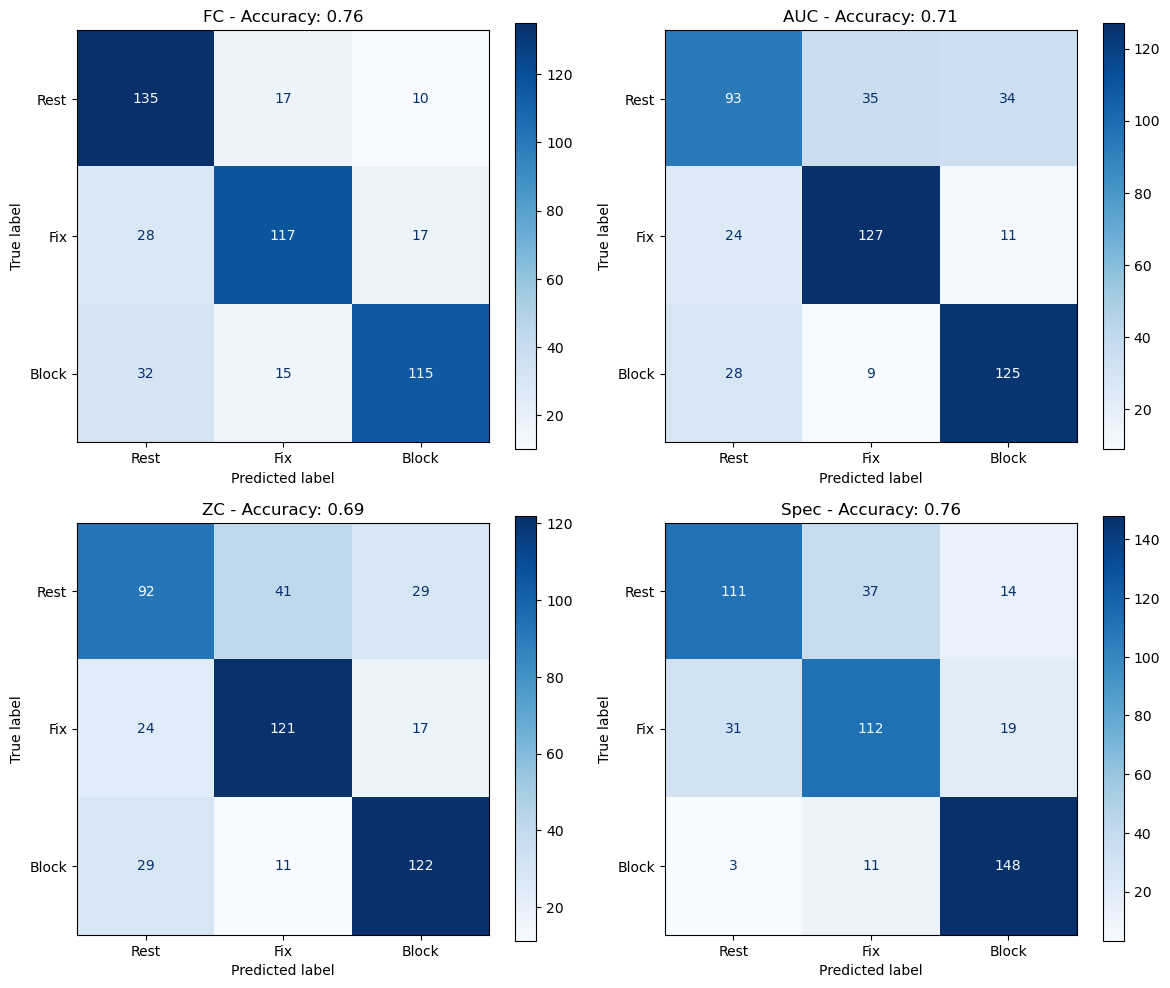

In [9]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

# --- Load data ---
fc_rest_all = np.load("rest_all_fc.npy")    # shape: (18, 19, 19, 9)
fc_fix_all = np.load("fix_all_fc.npy")
fc_block_all = np.load("block_all_fc.npy")

auc_rest_all = np.load("auc_rest_all.npy")  # shape: (subjects, electrodes, blocks)
auc_fix_all = np.load("auc_fix_all.npy")
auc_block_all = np.load("auc_block_all.npy")

zc_rest_all = np.load("zc_rest_all.npy")
zc_fix_all = np.load("zc_fix_all.npy")
zc_block_all = np.load("zc_block_all.npy")

spec_rest_all = np.load("spec_rest_all.npy")
spec_fix_all = np.load("spec_fix_all.npy")
spec_block_all = np.load("spec_block_all.npy")


# --- Reshape functions ---
def reshape_fc(fc_data):
    # Upper triangle only
    n_subjects, n_elec, _, n_blocks = fc_data.shape
    iu = np.triu_indices(n_elec, k=1)
    data = []
    for subj in range(n_subjects):
        for blk in range(n_blocks):
            mat = fc_data[subj, :, :, blk]
            vec = mat[iu]
            data.append(vec)
    return np.array(data)

def reshape_generic(data):
    n_subjects, n_elec, n_blocks = data.shape
    return np.vstack([data[subj, :, blk] for subj in range(n_subjects) for blk in range(n_blocks)])


# --- Main pipeline function ---
def run_model_pipeline(X, y, name, ax, n_permutations=1000):
    # Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Grid search SVM
    param_grid = {
        'C': [0.1, 1, 10],
        'gamma': [0.001, 0.01, 0.1],
        'kernel': ['rbf']
    }
    grid = GridSearchCV(SVC(), param_grid, cv=cv, scoring='accuracy')
    grid.fit(X_scaled, y)
    best_clf = grid.best_estimator_

    # Confusion matrix
    y_pred = cross_val_predict(best_clf, X_scaled, y, cv=cv)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rest", "Fix", "Block"])
    disp.plot(cmap='Blues', ax=ax)
    ax.set_title(f"{name} - Accuracy: {np.mean(grid.best_score_):.2f}")

    # Permutation test
    real_score = np.mean(cross_val_score(best_clf, X_scaled, y, cv=cv))
    perm_scores = []
    for _ in range(n_permutations):
        y_perm = shuffle(y, random_state=None)
        perm_score = np.mean(cross_val_score(best_clf, X_scaled, y_perm, cv=cv))
        perm_scores.append(perm_score)
    p_val = np.mean(np.array(perm_scores) >= real_score)
    print(f"{name} Accuracy: {real_score:.3f}, Permutation p-value: {p_val:.4f}")


# --- Prepare data and labels ---
X_fc = np.vstack([reshape_fc(fc_rest_all), reshape_fc(fc_fix_all), reshape_fc(fc_block_all)])
X_auc = np.vstack([reshape_generic(auc_rest_all), reshape_generic(auc_fix_all), reshape_generic(auc_block_all)])
X_zc  = np.vstack([reshape_generic(zc_rest_all), reshape_generic(zc_fix_all), reshape_generic(zc_block_all)])
X_spec = np.vstack([reshape_generic(spec_rest_all), reshape_generic(spec_fix_all), reshape_generic(spec_block_all)])

y = np.array([0]*162 + [1]*162 + [2]*162)  # assuming 18 subjects * 9 blocks * 3 conditions


# --- Plot and run ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

run_model_pipeline(X_fc,   y, "FC",   axes[0])
run_model_pipeline(X_auc,  y, "AUC",  axes[1])
run_model_pipeline(X_zc,   y, "ZC",   axes[2])
run_model_pipeline(X_spec, y, "Spec", axes[3])

plt.tight_layout()
plt.show()


FC Accuracy: 0.755, Permutation p-value: 0.00e+00
AUC Accuracy: 0.710, Permutation p-value: 0.00e+00
ZC Accuracy: 0.689, Permutation p-value: 0.00e+00
Spec Accuracy: 0.763, Permutation p-value: 0.00e+00


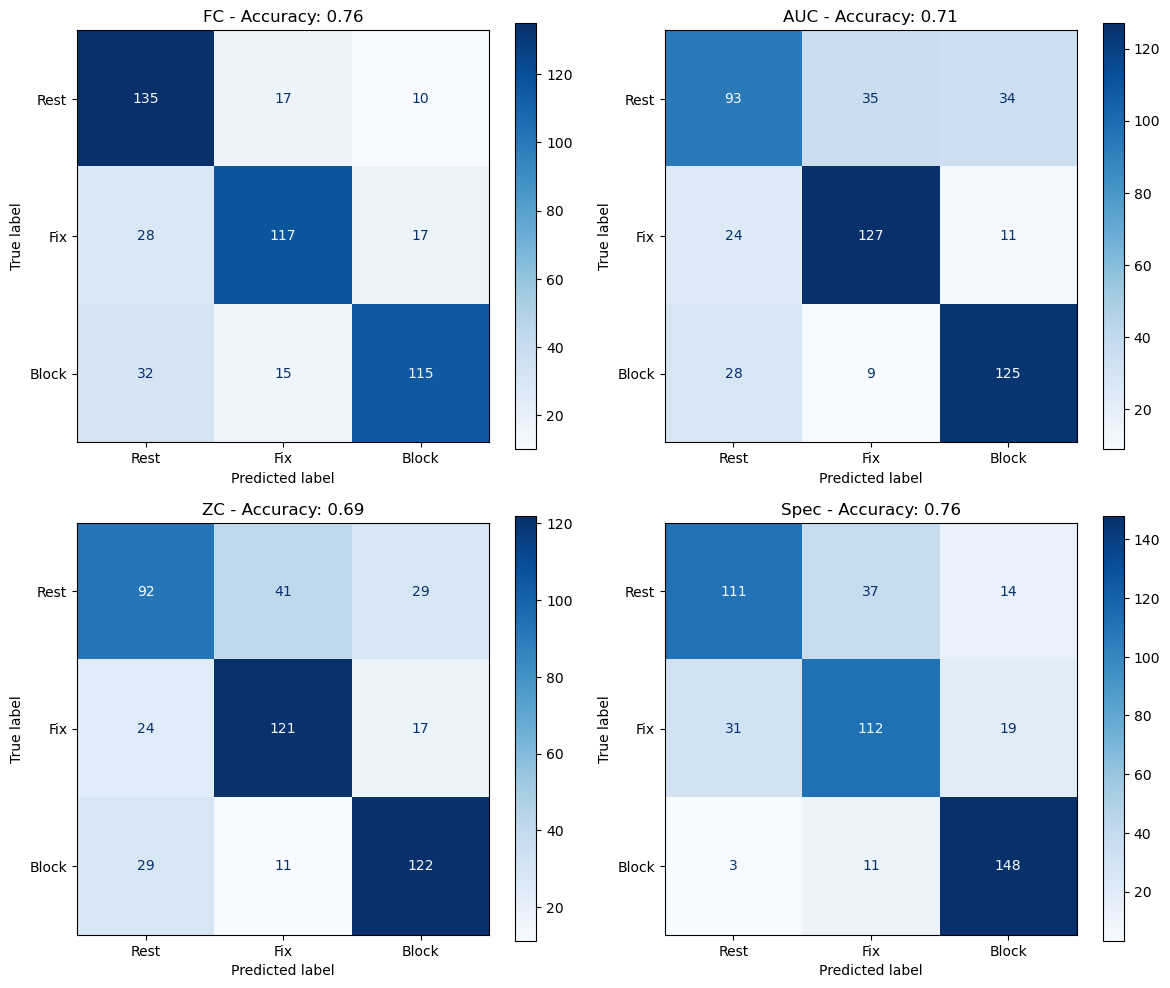

In [10]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

# --- Reshape functions unchanged ---

def reshape_fc(fc_data):
    n_subjects, n_elec, _, n_blocks = fc_data.shape
    iu = np.triu_indices(n_elec, k=1)
    data = []
    for subj in range(n_subjects):
        for blk in range(n_blocks):
            mat = fc_data[subj, :, :, blk]
            vec = mat[iu]
            data.append(vec)
    return np.array(data)

def reshape_generic(data):
    n_subjects, n_elec, n_blocks = data.shape
    return np.vstack([data[subj, :, blk] for subj in range(n_subjects) for blk in range(n_blocks)])


# --- Updated pipeline with fixed parameters and 200 permutations ---
def run_model_pipeline(X, y, name, ax, n_permutations=200):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Fixed SVM parameters, no grid search
    best_clf = SVC(C=10, gamma=0.1, kernel='rbf')

    # Confusion matrix with cross-validated predictions
    y_pred = cross_val_predict(best_clf, X_scaled, y, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rest", "Fix", "Block"])
    disp.plot(cmap='Blues', ax=ax)
    # Compute mean accuracy from predictions
    accuracy = np.mean(y_pred == y)
    ax.set_title(f"{name} - Accuracy: {accuracy:.2f}")

    # Real accuracy score with cross_val_score
    real_score = np.mean(cross_val_score(best_clf, X_scaled, y, cv=cv, n_jobs=-1))

    # Permutation test
    perm_scores = []
    for _ in range(n_permutations):
        y_perm = shuffle(y, random_state=None)
        perm_score = np.mean(cross_val_score(best_clf, X_scaled, y_perm, cv=cv, n_jobs=-1))
        perm_scores.append(perm_score)
    perm_scores = np.array(perm_scores)
    p_val = np.mean(perm_scores >= real_score)

    print(f"{name} Accuracy: {real_score:.3f}, Permutation p-value: {p_val:.2e}")

# --- Prepare data and labels as before ---
X_fc = np.vstack([reshape_fc(np.load("rest_all_fc.npy")),
                  reshape_fc(np.load("fix_all_fc.npy")),
                  reshape_fc(np.load("block_all_fc.npy"))])
X_auc = np.vstack([reshape_generic(np.load("auc_rest_all.npy")),
                  reshape_generic(np.load("auc_fix_all.npy")),
                  reshape_generic(np.load("auc_block_all.npy"))])
X_zc = np.vstack([reshape_generic(np.load("zc_rest_all.npy")),
                 reshape_generic(np.load("zc_fix_all.npy")),
                 reshape_generic(np.load("zc_block_all.npy"))])
X_spec = np.vstack([reshape_generic(np.load("spec_rest_all.npy")),
                   reshape_generic(np.load("spec_fix_all.npy")),
                   reshape_generic(np.load("spec_block_all.npy"))])

y = np.array([0]*162 + [1]*162 + [2]*162)  # 3 classes, balanced

# --- Plot and run ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

run_model_pipeline(X_fc, y, "FC", axes[0], n_permutations=200)
run_model_pipeline(X_auc, y, "AUC", axes[1], n_permutations=200)
run_model_pipeline(X_zc, y, "ZC", axes[2], n_permutations=200)
run_model_pipeline(X_spec, y, "Spec", axes[3], n_permutations=200)

plt.tight_layout()
plt.show()


FC Accuracy: 0.755, Permutation p-value: 4.98e-03
AUC Accuracy: 0.710, Permutation p-value: 4.98e-03
Tau Accuracy: 0.689, Permutation p-value: 4.98e-03
Spec Accuracy: 0.763, Permutation p-value: 4.98e-03


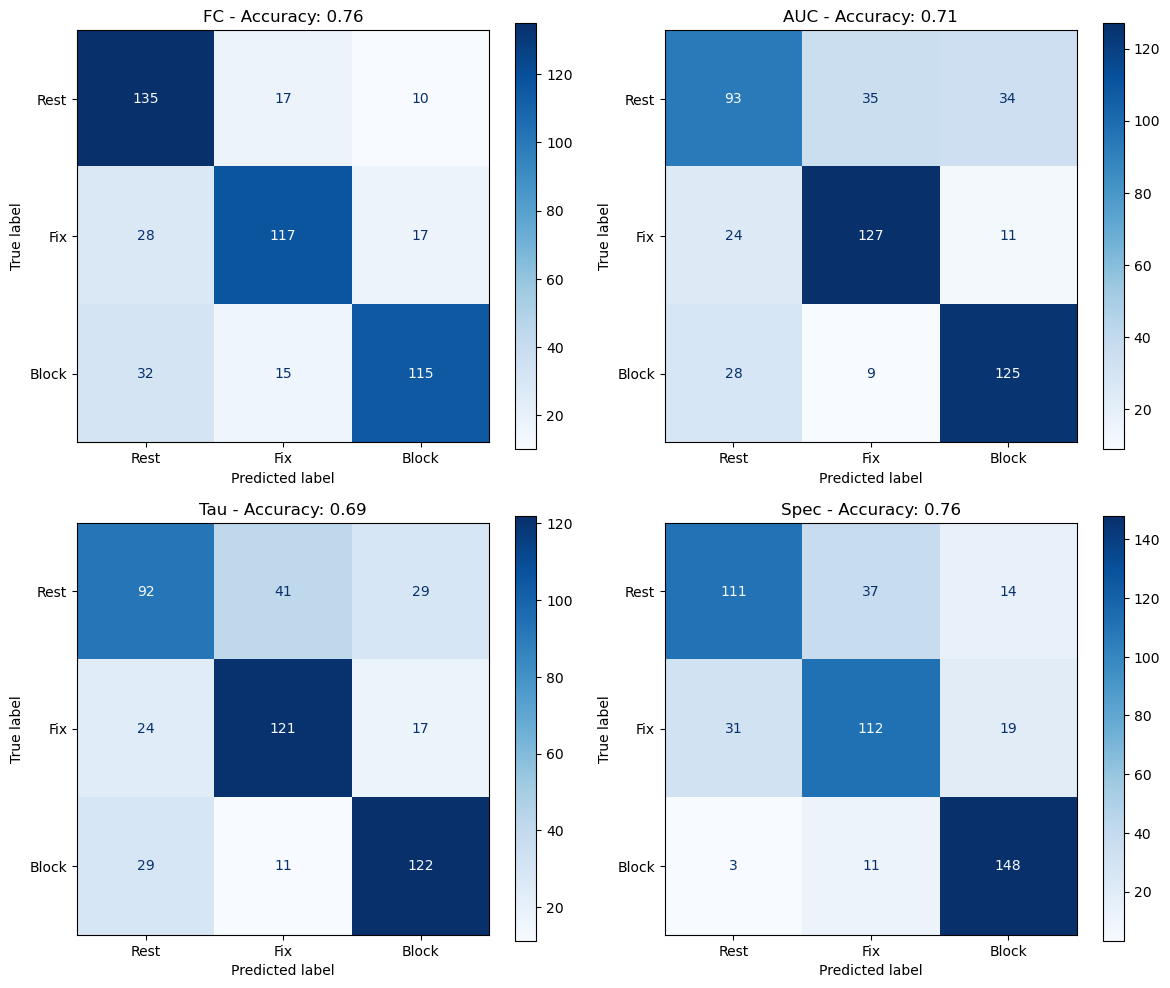

In [11]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

# --- Reshape functions ---
def reshape_fc(fc_data):
    n_subjects, n_elec, _, n_blocks = fc_data.shape
    iu = np.triu_indices(n_elec, k=1)
    data = []
    for subj in range(n_subjects):
        for blk in range(n_blocks):
            mat = fc_data[subj, :, :, blk]
            vec = mat[iu]
            data.append(vec)
    return np.array(data)

def reshape_generic(data):
    n_subjects, n_elec, n_blocks = data.shape
    return np.vstack([data[subj, :, blk] for subj in range(n_subjects) for blk in range(n_blocks)])


# --- Main pipeline function ---
def run_model_pipeline(X, y, name, ax, n_permutations=200):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Fixed SVM parameters, no grid search
    best_clf = SVC(C=10, gamma=0.1, kernel='rbf')

    # Confusion matrix with cross-validated predictions
    y_pred = cross_val_predict(best_clf, X_scaled, y, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rest", "Fix", "Block"])
    disp.plot(cmap='Blues', ax=ax)
    accuracy = np.mean(y_pred == y)
    ax.set_title(f"{name} - Accuracy: {accuracy:.2f}")

    # Real accuracy score with cross_val_score
    real_score = np.mean(cross_val_score(best_clf, X_scaled, y, cv=cv, n_jobs=-1))

    # Permutation test
    perm_scores = []
    for _ in range(n_permutations):
        y_perm = shuffle(y, random_state=None)
        perm_score = np.mean(cross_val_score(best_clf, X_scaled, y_perm, cv=cv, n_jobs=-1))
        perm_scores.append(perm_score)
    perm_scores = np.array(perm_scores)

    # Permutation p-value with +1 correction to avoid zero p-values
    p_val = (np.sum(perm_scores >= real_score) + 1) / (n_permutations + 1)

    print(f"{name} Accuracy: {real_score:.3f}, Permutation p-value: {p_val:.2e}")



# --- Load data ---
fc_rest_all = np.load("rest_all_fc.npy")    # shape: (18, 19, 19, 9)
fc_fix_all = np.load("fix_all_fc.npy")
fc_block_all = np.load("block_all_fc.npy")

auc_rest_all = np.load("auc_rest_all.npy")  # shape: (subjects, electrodes, blocks)
auc_fix_all = np.load("auc_fix_all.npy")
auc_block_all = np.load("auc_block_all.npy")

zc_rest_all = np.load("tau_rest_all.npy")
zc_fix_all = np.load("tau_fix_all.npy")
zc_block_all = np.load("tau_block_all.npy")

spec_rest_all = np.load("spec_rest_all.npy")
spec_fix_all = np.load("spec_fix_all.npy")
spec_block_all = np.load("spec_block_all.npy")


# --- Prepare data and labels ---
X_fc = np.vstack([reshape_fc(fc_rest_all), reshape_fc(fc_fix_all), reshape_fc(fc_block_all)])
X_auc = np.vstack([reshape_generic(auc_rest_all), reshape_generic(auc_fix_all), reshape_generic(auc_block_all)])
X_zc  = np.vstack([reshape_generic(zc_rest_all), reshape_generic(zc_fix_all), reshape_generic(zc_block_all)])
X_spec = np.vstack([reshape_generic(spec_rest_all), reshape_generic(spec_fix_all), reshape_generic(spec_block_all)])

y = np.array([0]*162 + [1]*162 + [2]*162)  # 3 classes balanced


# --- Plot and run ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

run_model_pipeline(X_fc,   y, "FC",   axes[0], n_permutations=200)
run_model_pipeline(X_auc,  y, "AUC",  axes[1], n_permutations=200)
run_model_pipeline(X_zc,   y, "Tau",   axes[2], n_permutations=200)
run_model_pipeline(X_spec, y, "Spec", axes[3], n_permutations=200)

plt.tight_layout()
plt.show()


FIX vs REST: t = -0.858, p = 0.4031
BLOCK vs FIX: t = 0.044, p = 0.9654
BLOCK vs REST: t = -0.708, p = 0.4886


C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Peter\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


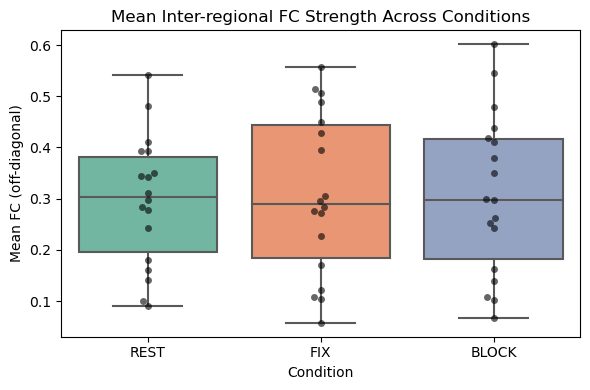

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import ttest_rel

# ---- FUNCTION DEFINITIONS ----

# Create a boolean mask to exclude diagonal (self-connections)
def get_off_diagonal_mask(n_electrodes):
    return ~np.eye(n_electrodes, dtype=bool)

# Compute mean inter-regional FC for each subject and sequence
def mean_fc_strength(fc_data):
    n_subjects, n_ch, _, n_seq = fc_data.shape
    mask = get_off_diagonal_mask(n_ch)
    mean_fc = np.zeros((n_subjects, n_seq))
    for subj in range(n_subjects):
        for seq in range(n_seq):
            matrix = fc_data[subj, :, :, seq]
            mean_fc[subj, seq] = matrix[mask].mean()
    return mean_fc  # shape: (n_subjects, n_seq)

# Run paired t-tests between conditions
def run_stats(fc1, fc2, label1, label2):
    t, p = ttest_rel(fc1, fc2)
    print(f"{label2} vs {label1}: t = {t:.3f}, p = {p:.4f}")
    return t, p

# Plot results
def plot_fc_distributions(fc_rest_avg, fc_fix_avg, fc_block_avg):
    df = pd.DataFrame({
        'REST': fc_rest_avg,
        'FIX': fc_fix_avg,
        'BLOCK': fc_block_avg
    })
    df_melted = df.melt(var_name='Condition', value_name='Mean_FC')

    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_melted, x='Condition', y='Mean_FC', palette='Set2')
    sns.swarmplot(data=df_melted, x='Condition', y='Mean_FC', color='black', alpha=0.6)
    plt.title('Mean Inter-regional FC Strength Across Conditions')
    plt.ylabel('Mean FC (off-diagonal)')
    plt.tight_layout()
    plt.show()

# ---- RUN ANALYSIS ----

# Assume you have already loaded these:
# fc_rest_all = np.load("rest_all_fc.npy")
# fc_fix_all = np.load("fix_all_fc.npy")
# fc_block_all = np.load("block_all_fc.npy")

# Step 1: Compute subject-wise mean FC across sequences
mean_fc_rest = mean_fc_strength(fc_rest_all)      # shape: (n_subjects, n_seq)
mean_fc_fix = mean_fc_strength(fc_fix_all)
mean_fc_block = mean_fc_strength(fc_block_all)

# Step 2: Average across sequences → one value per subject
mean_fc_rest_avg = mean_fc_rest.mean(axis=1)      # shape: (n_subjects,)
mean_fc_fix_avg = mean_fc_fix.mean(axis=1)
mean_fc_block_avg = mean_fc_block.mean(axis=1)

# Step 3: Run paired statistical comparisons
run_stats(mean_fc_rest_avg, mean_fc_fix_avg, 'REST', 'FIX')
run_stats(mean_fc_fix_avg, mean_fc_block_avg, 'FIX', 'BLOCK')
run_stats(mean_fc_rest_avg, mean_fc_block_avg, 'REST', 'BLOCK')

# Step 4: Plot results
plot_fc_distributions(mean_fc_rest_avg, mean_fc_fix_avg, mean_fc_block_avg)


FC - Accuracy: 0.747, AUC Macro: 0.902
AUC - Accuracy: 0.710, AUC Macro: 0.862
Tau - Accuracy: 0.689, AUC Macro: 0.856
Spec - Accuracy: 0.763, AUC Macro: 0.905


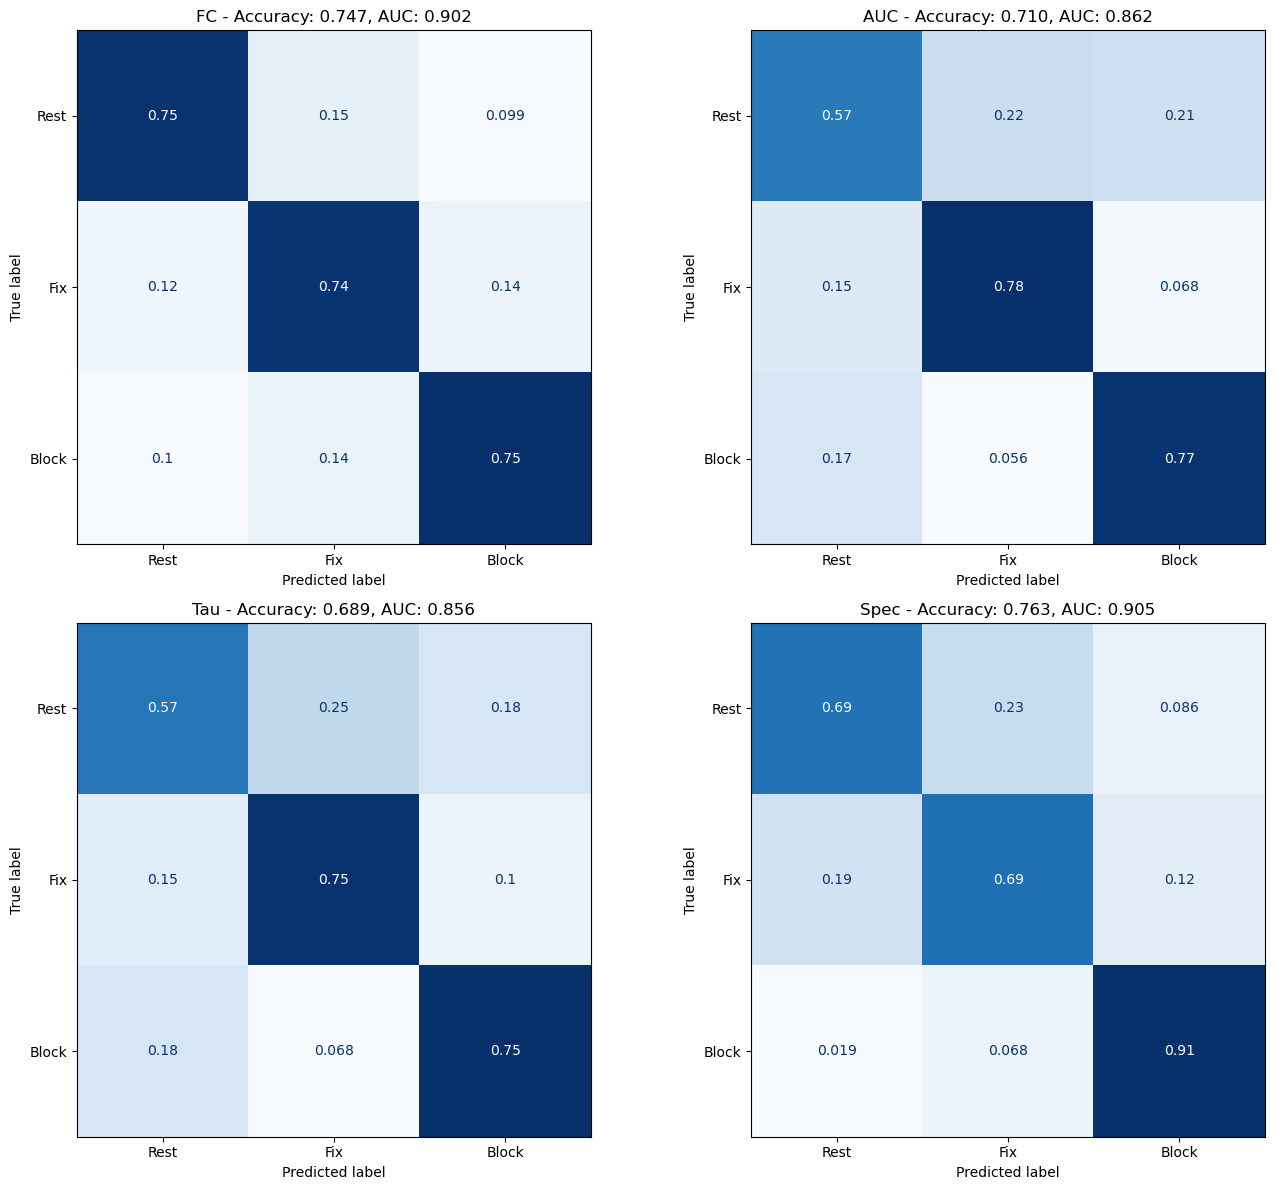

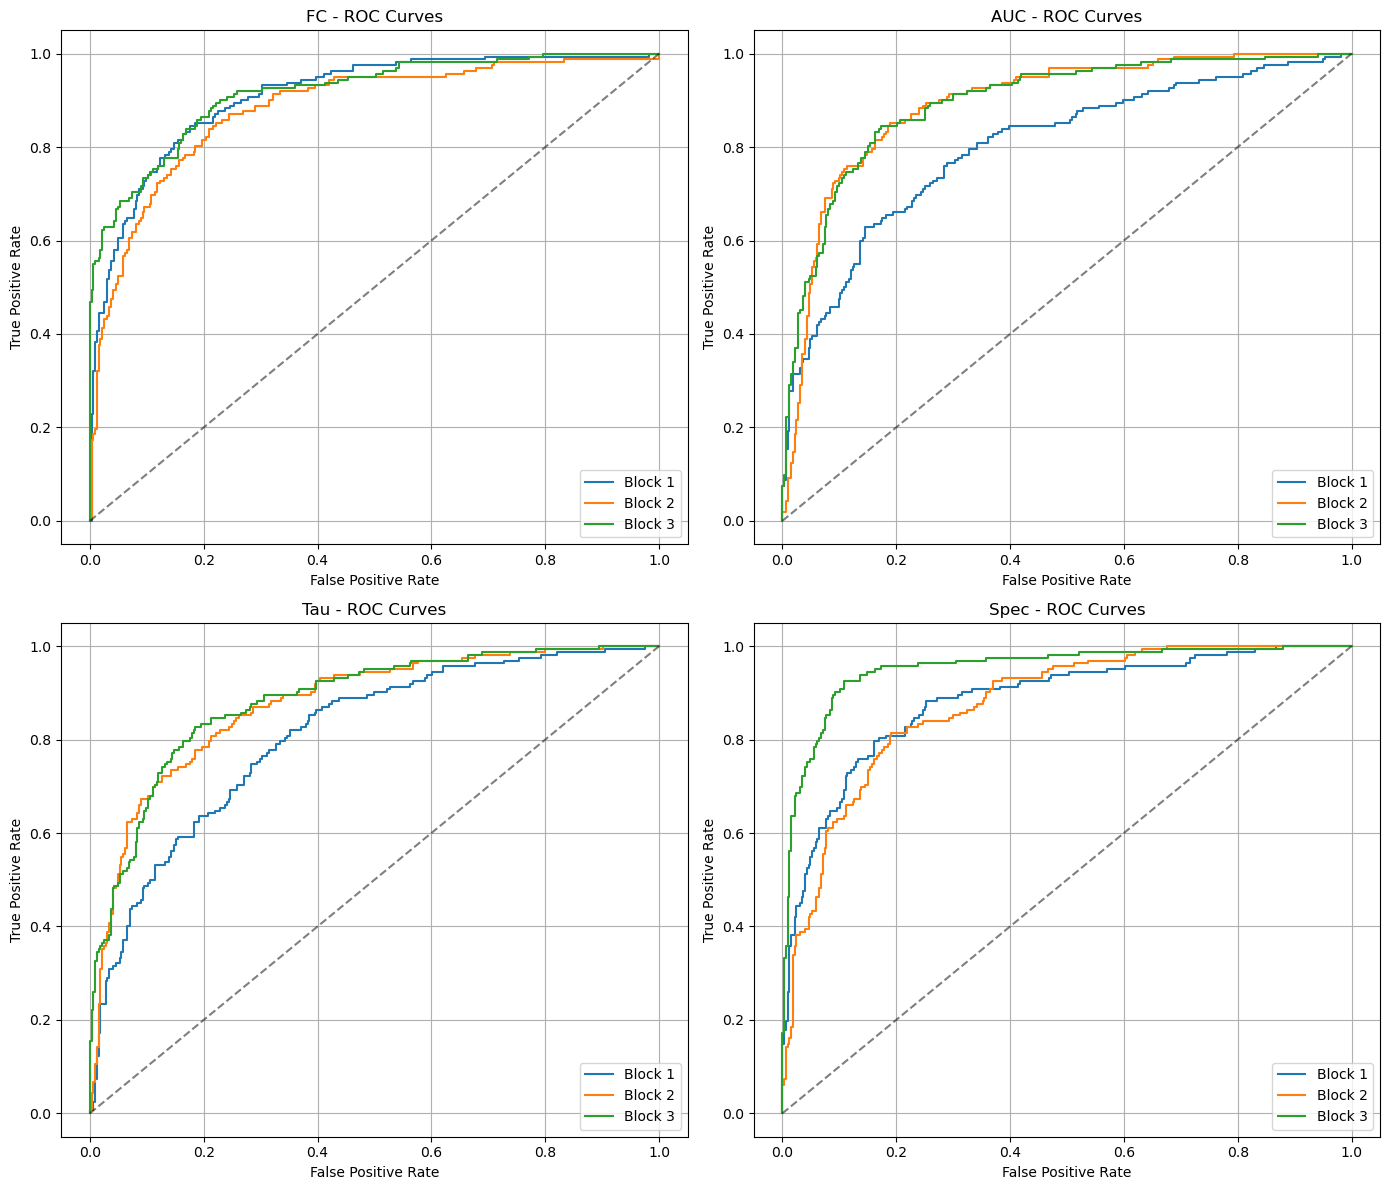

In [2]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

# --- Reshape functions ---
def reshape_fc(fc_data):
    n_subjects, n_elec, _, n_blocks = fc_data.shape
    iu = np.triu_indices(n_elec, k=1)
    data = []
    for subj in range(n_subjects):
        for blk in range(n_blocks):
            mat = fc_data[subj, :, :, blk]
            vec = mat[iu]
            data.append(vec)
    return np.array(data)

def reshape_generic(data):
    n_subjects, n_elec, n_blocks = data.shape
    return np.vstack([data[subj, :, blk] for subj in range(n_subjects) for blk in range(n_blocks)])


# --- Nested CV pipeline function ---
def run_nested_cv(X, y, param_grid=None, cv_outer=5, cv_inner=3):
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
    outer_cv = StratifiedKFold(n_splits=cv_outer, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=cv_inner, shuffle=True, random_state=1)
    
    best_params_per_fold = []
    y_true_all, y_pred_all, y_proba_all = [], [], []

    for train_idx, test_idx in outer_cv.split(X, y):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]

        # Grid search on inner CV
        best_score = -np.inf
        best_clf = None
        for C in param_grid['C']:
            for gamma in param_grid['gamma']:
                clf = SVC(C=C, gamma=gamma, kernel='rbf', probability=True)
                scores = []
                for inner_train, inner_val in inner_cv.split(X_train, y_train):
                    clf.fit(X_train[inner_train], y_train[inner_train])
                    scores.append(clf.score(X_train[inner_val], y_train[inner_val]))
                mean_score = np.mean(scores)
                if mean_score > best_score:
                    best_score = mean_score
                    best_clf = SVC(C=C, gamma=gamma, kernel='rbf', probability=True)
        best_clf.fit(X_train, y_train)
        y_pred = best_clf.predict(X_test)
        y_proba = best_clf.predict_proba(X_test)

        y_true_all.append(y_test)
        y_pred_all.append(y_pred)
        y_proba_all.append(y_proba)
        best_params_per_fold.append(best_clf.get_params())

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)
    y_proba_all = np.vstack(y_proba_all)

    accuracy = np.mean(y_true_all == y_pred_all)
    cm = confusion_matrix(y_true_all, y_pred_all)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    y_true_bin = label_binarize(y_true_all, classes=np.unique(y))
    auc_macro = roc_auc_score(y_true_bin, y_proba_all, average="macro", multi_class="ovr")

    return cm_norm, accuracy, auc_macro, y_true_bin, y_proba_all


# --- Load data ---
fc_rest_all = np.load("rest_all_fc.npy")    # shape: (18, 19, 19, 9)
fc_fix_all = np.load("fix_all_fc.npy")
fc_block_all = np.load("block_all_fc.npy")

auc_rest_all = np.load("auc_rest_all.npy")  # shape: (subjects, electrodes, blocks)
auc_fix_all = np.load("auc_fix_all.npy")
auc_block_all = np.load("auc_block_all.npy")

zc_rest_all = np.load("tau_rest_all.npy")
zc_fix_all = np.load("tau_fix_all.npy")
zc_block_all = np.load("tau_block_all.npy")

spec_rest_all = np.load("spec_rest_all.npy")
spec_fix_all = np.load("spec_fix_all.npy")
spec_block_all = np.load("spec_block_all.npy")


# --- Prepare data and labels ---
X_fc = np.vstack([reshape_fc(fc_rest_all), reshape_fc(fc_fix_all), reshape_fc(fc_block_all)])
X_auc = np.vstack([reshape_generic(auc_rest_all), reshape_generic(auc_fix_all), reshape_generic(auc_block_all)])
X_zc  = np.vstack([reshape_generic(zc_rest_all), reshape_generic(zc_fix_all), reshape_generic(zc_block_all)])
X_spec = np.vstack([reshape_generic(spec_rest_all), reshape_generic(spec_fix_all), reshape_generic(spec_block_all)])

# FIXED: add parentheses to avoid operator precedence error
y = np.array([0]*(X_fc.shape[0]//3) + [1]*(X_fc.shape[0]//3) + [2]*(X_fc.shape[0]//3))

param_grid = {'C': [0.1, 1, 10], 'gamma': [0.001, 0.01, 0.1]}


# --- Run nested CV and plot results ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

datasets = {
    "FC": X_fc,
    "AUC": X_auc,
    "Tau": X_zc,
    "Spec": X_spec
}

for i, (label, X_data) in enumerate(datasets.items()):
    cm_norm, acc, auc_macro, y_bin, y_proba = run_nested_cv(X_data, y, param_grid=param_grid)
    print(f"{label} - Accuracy: {acc:.3f}, AUC Macro: {auc_macro:.3f}")
    
    # Confusion matrix plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["Rest", "Fix", "Block"])
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(f"{label} - Accuracy: {acc:.3f}, AUC: {auc_macro:.3f}")

plt.tight_layout()
plt.show()


# --- Plot ROC curves in a new figure ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for i, (label, X_data) in enumerate(datasets.items()):
    _, _, _, y_bin, y_proba = run_nested_cv(X_data, y, param_grid=param_grid)
    
    n_classes = y_bin.shape[1]
    for j in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, j], y_proba[:, j])
        axes[i].plot(fpr, tpr, label=f"Block {j+1}")
    axes[i].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[i].set_title(f"{label} - ROC Curves")
    axes[i].set_xlabel("False Positive Rate")
    axes[i].set_ylabel("True Positive Rate")
    axes[i].legend(loc="lower right")
    axes[i].grid(True)

plt.tight_layout()
plt.show()


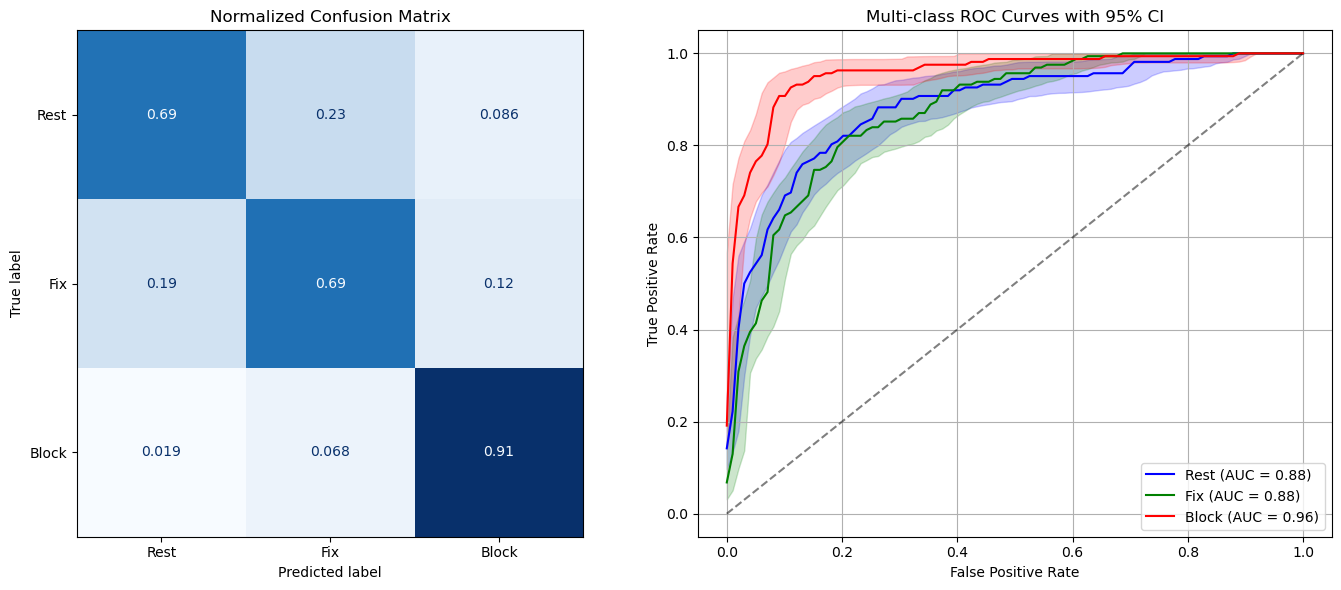

In [4]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.utils import resample
import matplotlib.pyplot as plt

# --- Reshape function for SPEC ---
def reshape_generic(data):
    n_subjects, n_elec, n_blocks = data.shape
    return np.vstack([data[subj, :, blk] for subj in range(n_subjects) for blk in range(n_blocks)])

# --- Nested CV for SPEC only ---
def run_nested_cv_spec(X, y, param_grid, cv_outer=5, cv_inner=3):
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    outer_cv = StratifiedKFold(n_splits=cv_outer, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=cv_inner, shuffle=True, random_state=1)

    y_true_all, y_pred_all, y_proba_all = [], [], []

    for train_idx, test_idx in outer_cv.split(X, y):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]

        best_score = -np.inf
        best_params = None

        # Grid search on inner folds
        for C in param_grid['C']:
            for gamma in param_grid['gamma']:
                clf = SVC(C=C, gamma=gamma, kernel='rbf', probability=True)
                scores = []
                for inner_train, inner_val in inner_cv.split(X_train, y_train):
                    clf.fit(X_train[inner_train], y_train[inner_train])
                    scores.append(clf.score(X_train[inner_val], y_train[inner_val]))
                mean_score = np.mean(scores)
                if mean_score > best_score:
                    best_score = mean_score
                    best_params = {'C': C, 'gamma': gamma}

        # Train best model on full train set
        best_clf = SVC(**best_params, kernel='rbf', probability=True)
        best_clf.fit(X_train, y_train)

        y_pred = best_clf.predict(X_test)
        y_proba = best_clf.predict_proba(X_test)

        y_true_all.append(y_test)
        y_pred_all.append(y_pred)
        y_proba_all.append(y_proba)

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)
    y_proba_all = np.vstack(y_proba_all)

    # Normalized confusion matrix
    cm = confusion_matrix(y_true_all, y_pred_all)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # Binarize labels for ROC
    y_true_bin = label_binarize(y_true_all, classes=np.unique(y))

    return cm_norm, y_true_bin, y_proba_all, y_true_all, y_pred_all

# --- Compute ROC curves and bootstrap CI for each class ---
def compute_roc_ci(y_true_bin, y_proba, n_bootstraps=1000, ci=0.95):
    n_classes = y_true_bin.shape[1]
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    tpr_lower = dict()
    tpr_upper = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

        # Bootstrap confidence intervals on TPR at fixed FPR points
        rng = np.random.RandomState(42)
        boot_tprs = []

        # Interpolate TPR at common FPR points
        base_fpr = np.linspace(0, 1, 100)
        interp_tpr = np.interp(base_fpr, fpr[i], tpr[i])
        
        for _ in range(n_bootstraps):
            indices = rng.randint(0, len(y_proba), len(y_proba))
            if len(np.unique(y_true_bin[indices, i])) < 2:
                # skip if bootstrap sample lacks positive or negative class
                continue
            fpr_bs, tpr_bs, _ = roc_curve(y_true_bin[indices, i], y_proba[indices, i])
            interp_tpr_bs = np.interp(base_fpr, fpr_bs, tpr_bs)
            boot_tprs.append(interp_tpr_bs)
        boot_tprs = np.array(boot_tprs)

        lower = np.percentile(boot_tprs, ((1 - ci) / 2) * 100, axis=0)
        upper = np.percentile(boot_tprs, (1 - (1 - ci) / 2) * 100, axis=0)
        
        tpr_lower[i] = lower
        tpr_upper[i] = upper
        fpr[i] = base_fpr
        tpr[i] = interp_tpr

    return fpr, tpr, roc_auc, tpr_lower, tpr_upper

# --- Load SPEC data ---
spec_rest_all = np.load("spec_rest_all.npy")
spec_fix_all = np.load("spec_fix_all.npy")
spec_block_all = np.load("spec_block_all.npy")

X_spec = np.vstack([reshape_generic(spec_rest_all), reshape_generic(spec_fix_all), reshape_generic(spec_block_all)])
y = np.array([0]*(X_spec.shape[0]//3) + [1]*(X_spec.shape[0]//3) + [2]*(X_spec.shape[0]//3))  # balanced labels

param_grid = {'C': [0.1, 1, 10], 'gamma': [0.001, 0.01, 0.1]}

# --- Run classification ---
cm_norm, y_true_bin, y_proba, y_true_all, y_pred_all = run_nested_cv_spec(X_spec, y, param_grid)

# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Confusion matrix plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["Rest", "Fix", "Block"])
disp.plot(ax=axs[0], cmap="Blues", colorbar=False)
axs[0].set_title("Normalized Confusion Matrix")

# ROC + CI plot
fpr, tpr, roc_auc, tpr_lower, tpr_upper = compute_roc_ci(y_true_bin, y_proba)

colors = ['blue', 'green', 'red']
labels = ["Rest", "Fix", "Block"]

for i, color in enumerate(colors):
    axs[1].plot(fpr[i], tpr[i], color=color, label=f"{labels[i]} (AUC = {roc_auc[i]:.2f})")
    axs[1].fill_between(fpr[i], tpr_lower[i], tpr_upper[i], color=color, alpha=0.2)

axs[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axs[1].set_xlabel("False Positive Rate")
axs[1].set_ylabel("True Positive Rate")
axs[1].set_title("Multi-class ROC Curves with 95% CI")
axs[1].legend(loc="lower right")
axs[1].grid(True)

plt.tight_layout()
plt.show()


Outer fold 1: best params = {'C': 10, 'gamma': 0.1}, inner CV score = 0.735
Outer fold 2: best params = {'C': 10, 'gamma': 0.1}, inner CV score = 0.728
Outer fold 3: best params = {'C': 10, 'gamma': 0.1}, inner CV score = 0.722
Outer fold 4: best params = {'C': 10, 'gamma': 0.1}, inner CV score = 0.758
Outer fold 5: best params = {'C': 10, 'gamma': 0.1}, inner CV score = 0.717


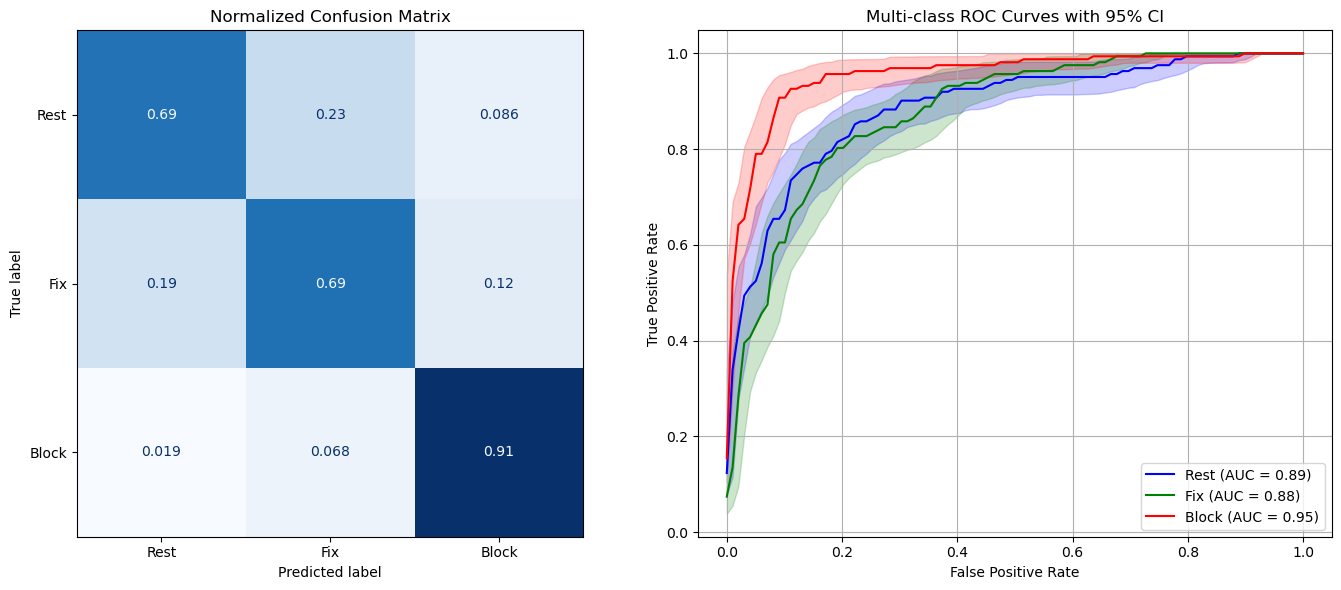

In [7]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# --- Reshape function for SPEC ---
def reshape_generic(data):
    n_subjects, n_elec, n_blocks = data.shape
    return np.vstack([data[subj, :, blk] for subj in range(n_subjects) for blk in range(n_blocks)])

# --- Nested CV with parameter optimization ---
def nested_cv_with_param_optimization(X, y, param_grid, cv_outer=5, cv_inner=3):
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    outer_cv = StratifiedKFold(n_splits=cv_outer, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=cv_inner, shuffle=True, random_state=1)

    y_true_all, y_pred_all, y_proba_all = [], [], []

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]

        best_score = -np.inf
        best_params = None

        # Inner loop parameter search
        for C in param_grid['C']:
            for gamma in param_grid['gamma']:
                clf = SVC(C=C, gamma=gamma, kernel='rbf', probability=True)
                inner_scores = []
                for inner_train, inner_val in inner_cv.split(X_train, y_train):
                    clf.fit(X_train[inner_train], y_train[inner_train])
                    inner_scores.append(clf.score(X_train[inner_val], y_train[inner_val]))
                mean_score = np.mean(inner_scores)
                if mean_score > best_score:
                    best_score = mean_score
                    best_params = {'C': C, 'gamma': gamma}

        print(f"Outer fold {fold_idx}: best params = {best_params}, inner CV score = {best_score:.3f}")

        # Train best model on full train fold
        best_clf = SVC(**best_params, kernel='rbf', probability=True)
        best_clf.fit(X_train, y_train)

        y_pred = best_clf.predict(X_test)
        y_proba = best_clf.predict_proba(X_test)

        y_true_all.append(y_test)
        y_pred_all.append(y_pred)
        y_proba_all.append(y_proba)

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)
    y_proba_all = np.vstack(y_proba_all)

    cm = confusion_matrix(y_true_all, y_pred_all)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    y_true_bin = label_binarize(y_true_all, classes=np.unique(y))

    return cm_norm, y_true_bin, y_proba_all, y_true_all, y_pred_all

# --- Compute ROC curves and bootstrap confidence intervals ---
def compute_roc_ci(y_true_bin, y_proba, n_bootstraps=1000, ci=0.95):
    n_classes = y_true_bin.shape[1]
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    tpr_lower = dict()
    tpr_upper = dict()

    rng = np.random.RandomState(42)
    base_fpr = np.linspace(0, 1, 100)

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        interp_tpr = np.interp(base_fpr, fpr[i], tpr[i])

        boot_tprs = []
        for _ in range(n_bootstraps):
            indices = rng.randint(0, len(y_proba), len(y_proba))
            if len(np.unique(y_true_bin[indices, i])) < 2:
                continue  # skip bootstrap samples without positive or negative class
            fpr_bs, tpr_bs, _ = roc_curve(y_true_bin[indices, i], y_proba[indices, i])
            interp_tpr_bs = np.interp(base_fpr, fpr_bs, tpr_bs)
            boot_tprs.append(interp_tpr_bs)
        boot_tprs = np.array(boot_tprs)

        lower = np.percentile(boot_tprs, (1 - ci) / 2 * 100, axis=0)
        upper = np.percentile(boot_tprs, (ci + (1 - ci) / 2) * 100, axis=0)

        fpr[i] = base_fpr
        tpr[i] = interp_tpr
        tpr_lower[i] = lower
        tpr_upper[i] = upper

    return fpr, tpr, roc_auc, tpr_lower, tpr_upper

# --- Main ---

# Load SPEC data arrays (assumed shape: subjects x electrodes x blocks)
spec_rest_all = np.load("spec_rest_all.npy")
spec_fix_all = np.load("spec_fix_all.npy")
spec_block_all = np.load("spec_block_all.npy")

# Stack and reshape SPEC data for all conditions
X_spec = np.vstack([
    reshape_generic(spec_rest_all),
    reshape_generic(spec_fix_all),
    reshape_generic(spec_block_all)
])

# Balanced labels: 0 = Rest, 1 = Fix, 2 = Block
y = np.array([0] * (X_spec.shape[0] // 3) + [1] * (X_spec.shape[0] // 3) + [2] * (X_spec.shape[0] // 3))

# Parameter grid for optimization
param_grid = {'C': [0.1, 1, 10], 'gamma': [0.001, 0.01, 0.1]}

# Run nested CV with parameter optimization
cm_norm, y_true_bin, y_proba, y_true_all, y_pred_all = nested_cv_with_param_optimization(X_spec, y, param_grid)

# Compute ROC curves with bootstrap confidence intervals
fpr, tpr, roc_auc, tpr_lower, tpr_upper = compute_roc_ci(y_true_bin, y_proba)

# Plot confusion matrix and ROC curves with CI
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["Rest", "Fix", "Block"])
disp.plot(ax=axs[0], cmap="Blues", colorbar=False)
axs[0].set_title("Normalized Confusion Matrix")

# ROC curves with CI
colors = ['blue', 'green', 'red']
labels = ["Rest", "Fix", "Block"]

for i, color in enumerate(colors):
    axs[1].plot(fpr[i], tpr[i], color=color, label=f"{labels[i]} (AUC = {roc_auc[i]:.2f})")
    axs[1].fill_between(fpr[i], tpr_lower[i], tpr_upper[i], color=color, alpha=0.2)

#axs[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axs[1].set_xlabel("False Positive Rate")
axs[1].set_ylabel("True Positive Rate")
axs[1].set_title("Multi-class ROC Curves with 95% CI")
axs[1].legend(loc="lower right")
axs[1].grid(True)

plt.tight_layout()
plt.show()


Outer fold 1: best params = {'C': 10, 'gamma': 1}, inner CV score = 0.732
Outer fold 2: best params = {'C': 10, 'gamma': 1}, inner CV score = 0.766
Outer fold 3: best params = {'C': 10, 'gamma': 1}, inner CV score = 0.735
Outer fold 4: best params = {'C': 10, 'gamma': 1}, inner CV score = 0.712
Outer fold 5: best params = {'C': 10, 'gamma': 1}, inner CV score = 0.722
Outer fold 1: best params = {'C': 10, 'gamma': 0.01}, inner CV score = 0.639
Outer fold 2: best params = {'C': 1, 'gamma': 0.01}, inner CV score = 0.666
Outer fold 3: best params = {'C': 1, 'gamma': 0.01}, inner CV score = 0.650
Outer fold 4: best params = {'C': 10, 'gamma': 0.01}, inner CV score = 0.710
Outer fold 5: best params = {'C': 1, 'gamma': 0.01}, inner CV score = 0.656
Outer fold 1: best params = {'C': 10, 'gamma': 0.1}, inner CV score = 0.727
Outer fold 2: best params = {'C': 10, 'gamma': 0.1}, inner CV score = 0.738
Outer fold 3: best params = {'C': 10, 'gamma': 0.1}, inner CV score = 0.699
Outer fold 4: best p

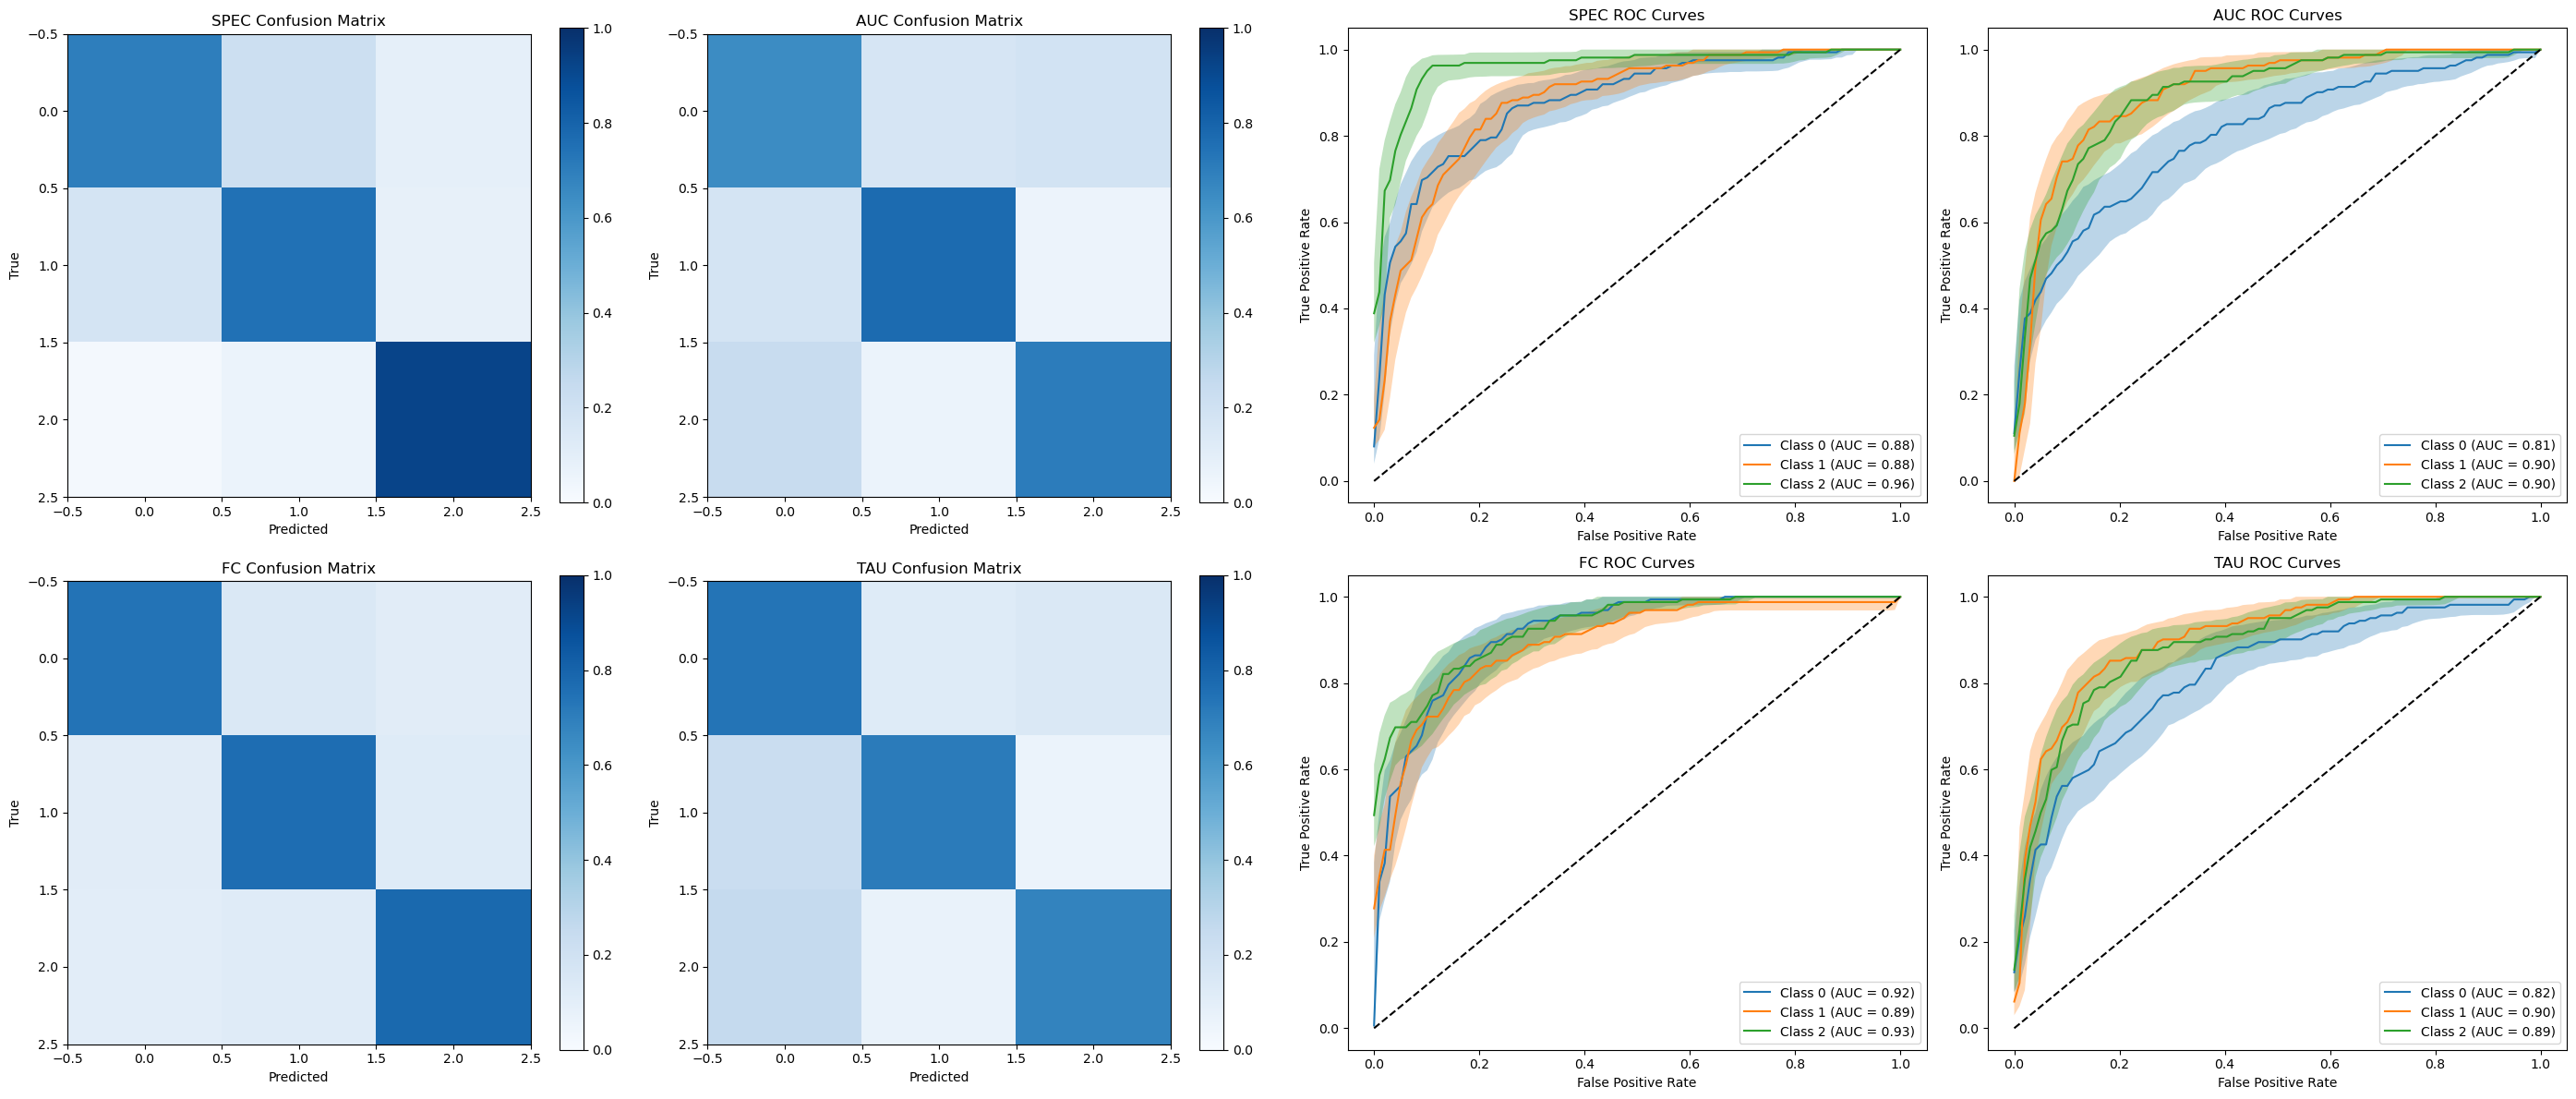

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# --- Load your data ---

# Example: if saved as separate .npy files per variable, in the current directory:
spec_rest = np.load("spec_rest_all.npy")    # shape (n_subjects, n_features, n_blocks)
spec_fix = np.load("spec_fix_all.npy")
spec_block = np.load("spec_block_all.npy")

auc_rest = np.load("auc_rest_all.npy")
auc_fix = np.load("auc_fix_all.npy")
auc_block = np.load("auc_block_all.npy")

tau_rest = np.load("tau_rest_all.npy")
tau_fix = np.load("tau_fix_all.npy")
tau_block = np.load("tau_block_all.npy")

fc_rest = np.load("rest_all_fc.npy")        # shape (n_subjects, 19, 19, n_blocks)
fc_fix = np.load("fix_all_fc.npy")
fc_block = np.load("block_all_fc.npy")

# --- Helper functions ---

def reshape_generic(data):
    n_subjects, n_features, n_blocks = data.shape
    return np.vstack([data[subj, :, blk] for subj in range(n_subjects) for blk in range(n_blocks)])

def reshape_fc(data):
    n_subjects, f1, f2, n_blocks = data.shape
    return np.vstack([data[subj].reshape(f1 * f2, n_blocks).T for subj in range(n_subjects)])

def nested_cv_with_param_optimization(X, y, param_grid):
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    y_true_all = []
    y_pred_all = []
    y_proba_all = []

    for i, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        grid = GridSearchCV(SVC(kernel='rbf', probability=True), param_grid, cv=inner_cv)
        grid.fit(X_train, y_train)

        print(f"Outer fold {i}: best params = {grid.best_params_}, inner CV score = {grid.best_score_:.3f}")

        y_pred = grid.predict(X_test)
        y_proba = grid.predict_proba(X_test)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)
        y_proba_all.extend(y_proba)

    cm = confusion_matrix(y_true_all, y_pred_all)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    y_true_bin = label_binarize(y_true_all, classes=[0, 1, 2])
    y_proba_all = np.array(y_proba_all)

    return cm_norm, y_true_bin, y_proba_all

def compute_roc_ci(y_true_bin, y_proba, n_bootstraps=1000, ci=0.95):
    n_classes = y_true_bin.shape[1]
    fpr, tpr, roc_auc, tpr_lower, tpr_upper = {}, {}, {}, {}, {}

    base_fpr = np.linspace(0, 1, 100)

    rng = np.random.RandomState(42)

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

        boot_tprs = []
        for _ in range(n_bootstraps):
            indices = rng.randint(0, len(y_proba), len(y_proba))
            if len(np.unique(y_true_bin[indices, i])) < 2:
                continue
            fpr_bs, tpr_bs, _ = roc_curve(y_true_bin[indices, i], y_proba[indices, i])
            interp_tpr_bs = np.interp(base_fpr, fpr_bs, tpr_bs)
            boot_tprs.append(interp_tpr_bs)

        boot_tprs = np.array(boot_tprs)
        tpr_lower[i] = np.percentile(boot_tprs, (1 - ci) / 2 * 100, axis=0)
        tpr_upper[i] = np.percentile(boot_tprs, (1 + ci) / 2 * 100, axis=0)

        tpr_interp = np.interp(base_fpr, fpr[i], tpr[i])
        fpr[i] = base_fpr
        tpr[i] = tpr_interp

    return fpr, tpr, roc_auc, tpr_lower, tpr_upper

def run_analysis(rest, fix, block, label):
    param_grid = {'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1]}

    if label == "FC":
        X_rest = reshape_fc(rest)
        X_fix = reshape_fc(fix)
        X_block = reshape_fc(block)
    else:
        X_rest = reshape_generic(rest)
        X_fix = reshape_generic(fix)
        X_block = reshape_generic(block)

    X = np.vstack([X_rest, X_fix, X_block])
    y = np.array([0] * len(X_rest) + [1] * len(X_fix) + [2] * len(X_block))

    cm_norm, y_true_bin, y_proba = nested_cv_with_param_optimization(X, y, param_grid)
    fpr, tpr, roc_auc, tpr_lower, tpr_upper = compute_roc_ci(y_true_bin, y_proba)

    return cm_norm, fpr, tpr, roc_auc, tpr_lower, tpr_upper

# --- Run analyses ---

results = {}
for label, (rest, fix, block) in {
    "SPEC": (spec_rest, spec_fix, spec_block),
    "AUC": (auc_rest, auc_fix, auc_block),
    "FC": (fc_rest, fc_fix, fc_block),
    "TAU": (tau_rest, tau_fix, tau_block)
}.items():
    results[label] = run_analysis(rest, fix, block, label)

# --- Plotting ---

fig, axs = plt.subplots(2, 4, figsize=(28, 12))

for col, label in enumerate(["SPEC", "AUC", "FC", "TAU"]):
    cm_norm, fpr, tpr, roc_auc, tpr_lower, tpr_upper = results[label]

    ax_cm = axs[0, col % 2] if col < 2 else axs[1, col % 2]
    im = ax_cm.imshow(cm_norm, vmin=0, vmax=1, cmap="Blues")
    ax_cm.set_title(f"{label} Confusion Matrix")
    ax_cm.set_xlabel("Predicted")
    ax_cm.set_ylabel("True")
    fig.colorbar(im, ax=ax_cm)

    ax_roc = axs[0, 2 + (col % 2)] if col < 2 else axs[1, 2 + (col % 2)]
    for i in range(3):
        ax_roc.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
        ax_roc.fill_between(fpr[i], tpr_lower[i], tpr_upper[i], alpha=0.3)
    ax_roc.plot([0, 1], [0, 1], "k--")
    ax_roc.set_title(f"{label} ROC Curves")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.legend(loc="lower right")

plt.tight_layout()
plt.show()


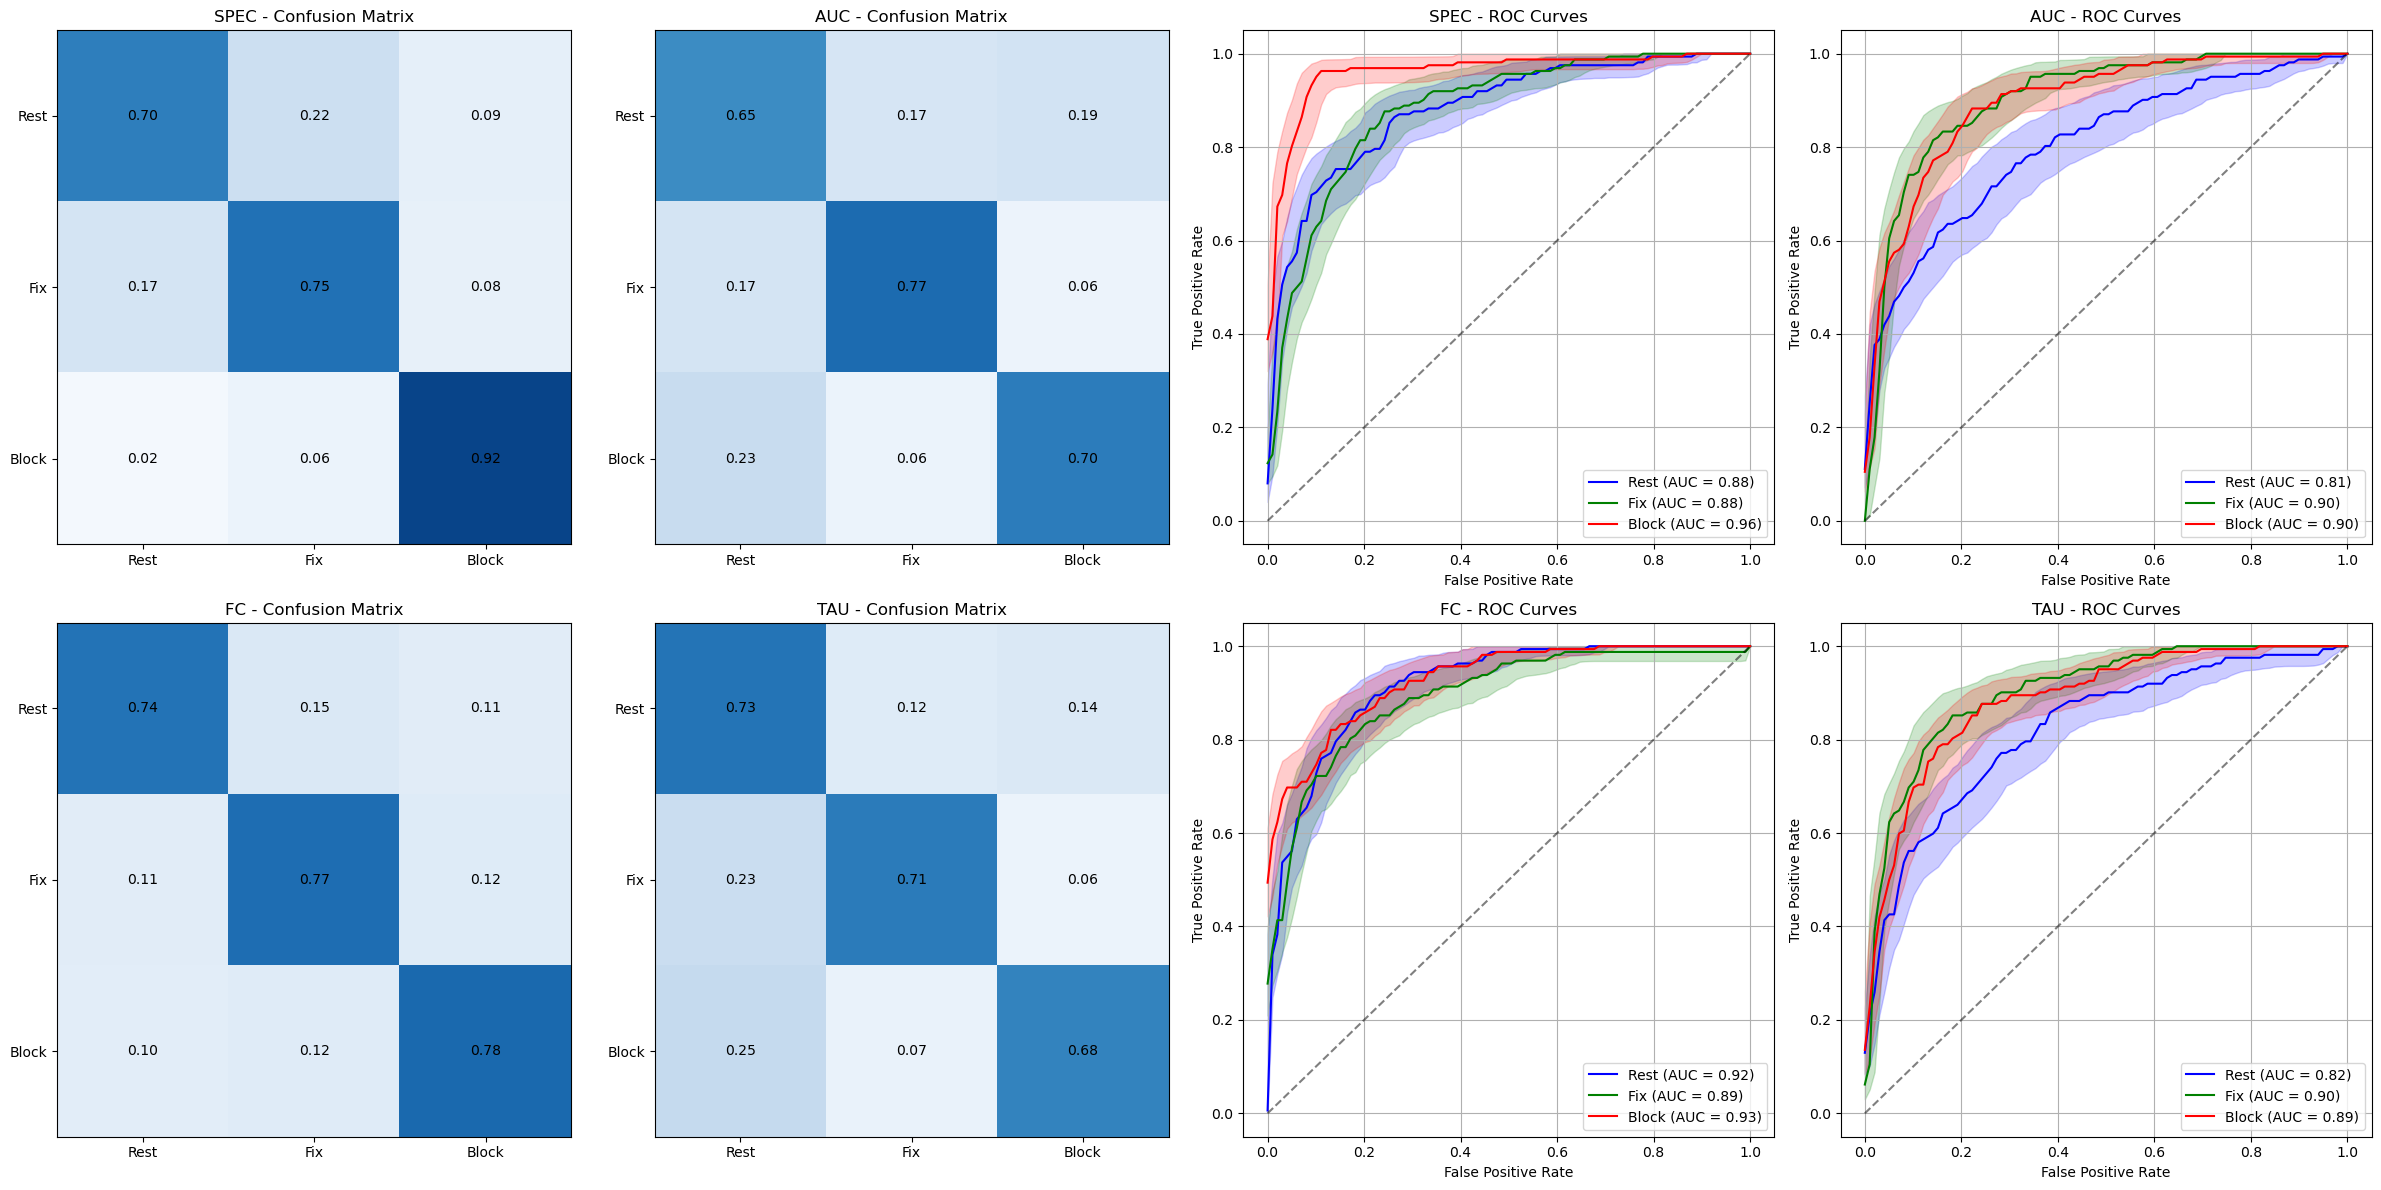

In [22]:
# --- Plotting big figure ---
fig, axs = plt.subplots(2, 4, figsize=(24, 12))
labels = ["Rest", "Fix", "Block"]
colors = ['blue', 'green', 'red']
plot_order = ["SPEC", "AUC", "FC", "TAU"]

for i, label in enumerate(plot_order):
    cm, fpr, tpr, roc_auc, tpr_lower, tpr_upper = results[label]
    row = i // 2
    col = i % 2  # Determines position within the row

    # Confusion matrix in columns 0 and 1
    ax_cm = axs[row, col]
    im = ax_cm.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues, vmin=0, vmax=1)
    ax_cm.set_title(f"{label} - Confusion Matrix")
    ax_cm.set_xticks(np.arange(3))
    ax_cm.set_yticks(np.arange(3))
    ax_cm.set_xticklabels(labels)
    ax_cm.set_yticklabels(labels)
    for j in range(3):
        for k in range(3):
            ax_cm.text(k, j, f"{cm[j, k]:.2f}", ha="center", va="center", color="black")

    # ROC curves in columns 2 and 3
    ax_roc = axs[row, col + 2]
    for j, color in enumerate(colors):
        ax_roc.plot(fpr[j], tpr[j], color=color, label=f"{labels[j]} (AUC = {roc_auc[j]:.2f})")
        ax_roc.fill_between(fpr[j], tpr_lower[j], tpr_upper[j], color=color, alpha=0.2)
    ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax_roc.set_title(f"{label} - ROC Curves")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.legend(loc="lower right")
    ax_roc.grid(True)

plt.tight_layout()
plt.show()


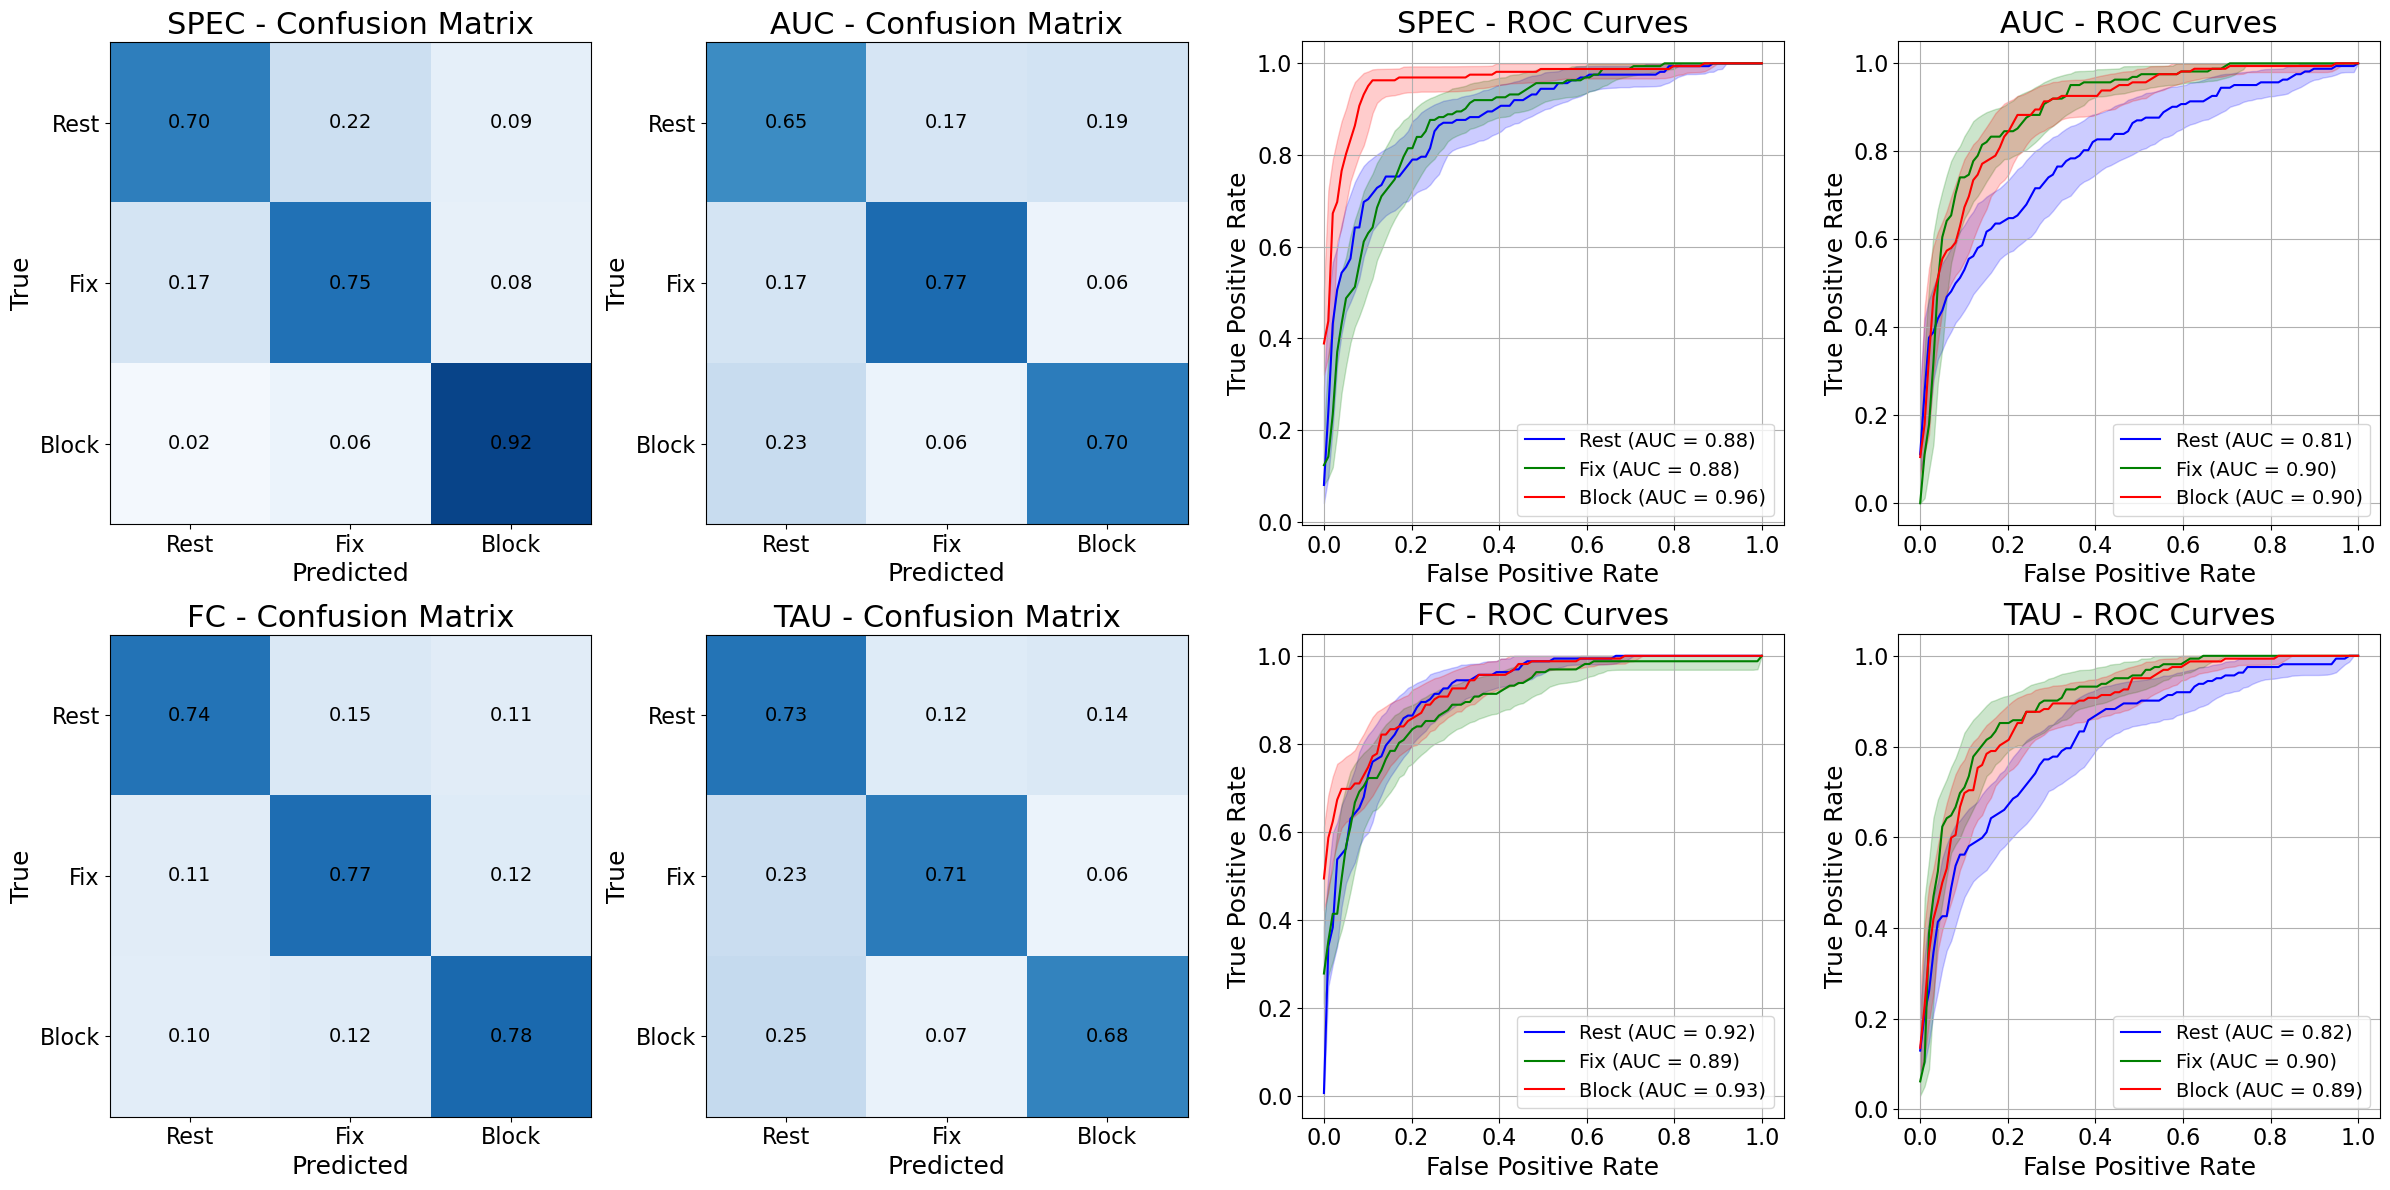

In [24]:
# --- Plotting big figure ---
fig, axs = plt.subplots(2, 4, figsize=(24, 12))
labels = ["Rest", "Fix", "Block"]
colors = ['blue', 'green', 'red']
plot_order = ["SPEC", "AUC", "FC", "TAU"]

title_fontsize = 22
label_fontsize = 18
ticks_fontsize = 16
legend_fontsize = 14
text_fontsize = 14

for i, label in enumerate(plot_order):
    cm, fpr, tpr, roc_auc, tpr_lower, tpr_upper = results[label]
    row = i // 2
    col = i % 2  # Determines position within the row

    # Confusion matrix in columns 0 and 1
    ax_cm = axs[row, col]
    im = ax_cm.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues, vmin=0, vmax=1)
    ax_cm.set_title(f"{label} - Confusion Matrix", fontsize=title_fontsize)
    ax_cm.set_xticks(np.arange(3))
    ax_cm.set_yticks(np.arange(3))
    ax_cm.set_xticklabels(labels, fontsize=ticks_fontsize)
    ax_cm.set_yticklabels(labels, fontsize=ticks_fontsize)
    ax_cm.set_xlabel("Predicted", fontsize=label_fontsize)
    ax_cm.set_ylabel("True", fontsize=label_fontsize)
    for j in range(3):
        for k in range(3):
            ax_cm.text(k, j, f"{cm[j, k]:.2f}", ha="center", va="center", color="black", fontsize=text_fontsize)

    # ROC curves in columns 2 and 3
    ax_roc = axs[row, col + 2]
    for j, color in enumerate(colors):
        ax_roc.plot(fpr[j], tpr[j], color=color, label=f"{labels[j]} (AUC = {roc_auc[j]:.2f})")
        ax_roc.fill_between(fpr[j], tpr_lower[j], tpr_upper[j], color=color, alpha=0.2)
    #ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax_roc.set_title(f"{label} - ROC Curves", fontsize=title_fontsize)
    ax_roc.set_xlabel("False Positive Rate", fontsize=label_fontsize)
    ax_roc.set_ylabel("True Positive Rate", fontsize=label_fontsize)
    ax_roc.legend(loc="lower right", fontsize=legend_fontsize)
    ax_roc.tick_params(axis='both', which='major', labelsize=ticks_fontsize)
    ax_roc.grid(True)

plt.tight_layout()
plt.show()


Running LOSO Decoding on 18 subjects...
Total samples: 486 | Features: 19


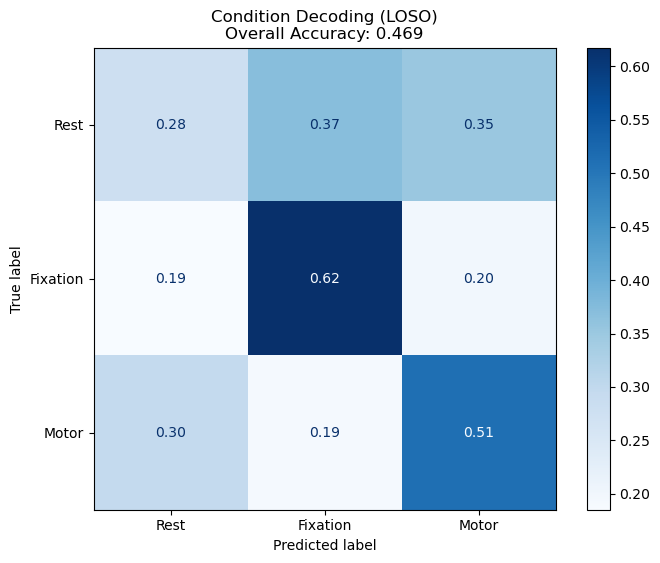


--- Classification Report ---
              precision    recall  f1-score   support

        Rest       0.37      0.28      0.32       162
    Fixation       0.52      0.62      0.57       162
       Motor       0.48      0.51      0.50       162

    accuracy                           0.47       486
   macro avg       0.46      0.47      0.46       486
weighted avg       0.46      0.47      0.46       486



In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# -------------------------------
# 1. Prepare the Data
# -------------------------------
# Load shapes: (subjects, electrodes, blocks)
tau_rest = np.load("auc_rest_all.npy")
tau_fix = np.load("auc_fix_all.npy")
tau_motor = np.load("auc_block_all.npy")

n_subs, n_elecs, n_blocks = tau_rest.shape

# We want to stack these so our classes are the 3 conditions
# X will be (Subjects * Blocks * 3, Electrodes)
X_rest = tau_rest.transpose(0, 2, 1).reshape(-1, n_elecs)
X_fix = tau_fix.transpose(0, 2, 1).reshape(-1, n_elecs)
X_motor = tau_motor.transpose(0, 2, 1).reshape(-1, n_elecs)

X = np.vstack([X_rest, X_fix, X_motor])

# Create Labels: 0=Rest, 1=Fixation, 2=Motor
y = np.concatenate([
    np.zeros(X_rest.shape[0]),
    np.ones(X_fix.shape[0]),
    np.indices((X_motor.shape[0],))[0] * 0 + 2 # Efficient way to fill 2s
])

# Create Groups (Subject IDs) to prevent leakage
# Each condition has (n_subs * n_blocks) samples. 
# We repeat the subject index n_blocks times for each condition.
sub_ids = np.tile(np.repeat(np.arange(n_subs), n_blocks), 3)

# -------------------------------
# 2. LOSO Classification
# -------------------------------
clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0))
logo = LeaveOneGroupOut()

print(f"Running LOSO Decoding on {n_subs} subjects...")
print(f"Total samples: {len(y)} | Features: {n_elecs}")

# Cross-validated predictions
y_pred = cross_val_predict(clf, X, y, cv=logo, groups=sub_ids, n_jobs=-1)

# -------------------------------
# 3. Evaluation & Visualization
# -------------------------------
acc = np.mean(y_pred == y)
cm = confusion_matrix(y, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm, 
    display_labels=["Rest", "Fixation", "Motor"]
)
disp.plot(cmap="Blues", ax=ax, values_format=".2f")
ax.set_title(f"Condition Decoding (LOSO)\nOverall Accuracy: {acc:.3f}")
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y, y_pred, target_names=["Rest", "Fixation", "Motor"]))

Starting Optimized LOSO Decoding...


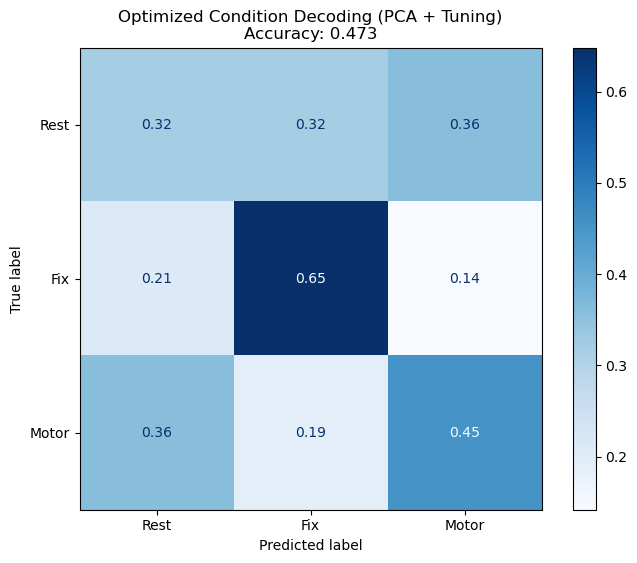

              precision    recall  f1-score   support

        Rest       0.36      0.32      0.34       162
         Fix       0.56      0.65      0.60       162
       Motor       0.47      0.45      0.46       162

    accuracy                           0.47       486
   macro avg       0.46      0.47      0.47       486
weighted avg       0.46      0.47      0.47       486



In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# --- Data Preparation (Same as before) ---
tau_rest = np.load("tau_rest_all.npy")
tau_fix = np.load("tau_fix_all.npy")
tau_motor = np.load("tau_block_all.npy")

n_subs, n_elecs, n_blocks = tau_rest.shape
X = np.vstack([
    tau_rest.transpose(0, 2, 1).reshape(-1, n_elecs),
    tau_fix.transpose(0, 2, 1).reshape(-1, n_elecs),
    tau_motor.transpose(0, 2, 1).reshape(-1, n_elecs)
])
y = np.concatenate([np.zeros(n_subs*n_blocks), np.ones(n_subs*n_blocks), np.full(n_subs*n_blocks, 2)])
sub_ids = np.tile(np.repeat(np.arange(n_subs), n_blocks), 3)

# --- The Advanced Pipeline ---
# 1. Scale data
# 2. PCA to remove noise (keep 95% of variance)
# 3. SVM with RBF kernel
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)), 
    ('svc', SVC(kernel='rbf', class_weight='balanced'))
])

# Hyperparameter grid to search over
param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 0.01, 0.1]
}

# Nested Search: Find best params for each LOSO fold
clf = GridSearchCV(pipe, param_grid, cv=3, n_jobs=-1) 
logo = LeaveOneGroupOut()

print("Starting Optimized LOSO Decoding...")
y_pred = cross_val_predict(clf, X, y, cv=logo, groups=sub_ids, n_jobs=-1)

# --- Results ---
acc = np.mean(y_pred == y)
cm = confusion_matrix(y, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm_norm, display_labels=["Rest", "Fix", "Motor"])
disp.plot(cmap="Blues", ax=ax, values_format=".2f")
ax.set_title(f"Optimized Condition Decoding (PCA + Tuning)\nAccuracy: {acc:.3f}")
plt.show()

print(classification_report(y, y_pred, target_names=["Rest", "Fix", "Motor"]))

Running Spatial Filter LOSO (Top 20 Electrodes)...
Top Electrode Indices: [ 5  6  8 17 18]


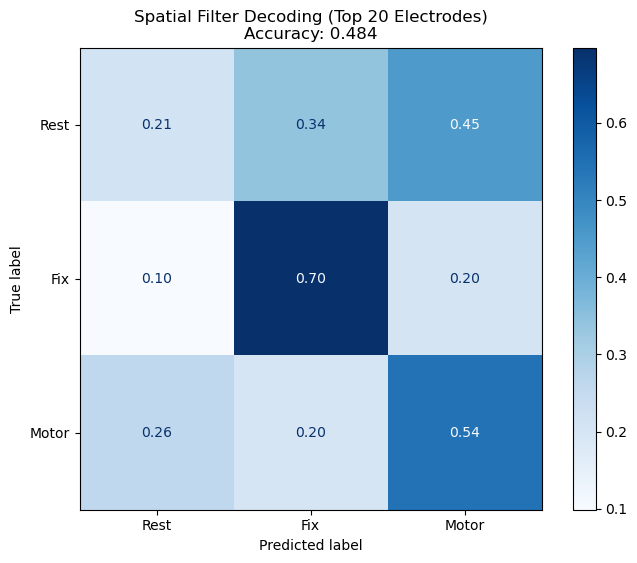

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Data Preparation ---
tau_rest = np.load("tau_rest_all.npy")
tau_fix = np.load("tau_fix_all.npy")
tau_motor = np.load("tau_block_all.npy")

n_subs, n_elecs, n_blocks = tau_rest.shape
X = np.vstack([
    tau_rest.transpose(0, 2, 1).reshape(-1, n_elecs),
    tau_fix.transpose(0, 2, 1).reshape(-1, n_elecs),
    tau_motor.transpose(0, 2, 1).reshape(-1, n_elecs)
])
y = np.concatenate([np.zeros(n_subs*n_blocks), np.ones(n_subs*n_blocks), np.full(n_subs*n_blocks, 2)])
sub_ids = np.tile(np.repeat(np.arange(n_subs), n_blocks), 3)

# --- Spatial Filter Pipeline ---
# Instead of PCA, we use SelectKBest to find the top 'K' electrodes 
# that statistically vary the most between our 3 conditions.
pipe_spatial = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_select', SelectKBest(f_classif, k=5)), # Keep only the top 20 electrodes
    ('svc', SVC(kernel='rbf', C=1.0, class_weight='balanced'))
])

logo = LeaveOneGroupOut()

print(f"Running Spatial Filter LOSO (Top 20 Electrodes)...")
y_pred = cross_val_predict(pipe_spatial, X, y, cv=logo, groups=sub_ids, n_jobs=-1)

# --- Analysis of Selected Features ---
# To see WHICH electrodes were chosen, we fit it once on the whole set
pipe_spatial.fit(X, y)
selected_indices = pipe_spatial.named_steps['feature_select'].get_support(indices=True)
print(f"Top Electrode Indices: {selected_indices}")

# --- Results ---
acc = np.mean(y_pred == y)
cm_norm = confusion_matrix(y, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm_norm, display_labels=["Rest", "Fix", "Motor"])
disp.plot(cmap="Blues", ax=ax, values_format=".2f")
ax.set_title(f"Spatial Filter Decoding (Top 20 Electrodes)\nAccuracy: {acc:.3f}")
plt.show()

Processing Feature Set: SPEC...
Processing Feature Set: AUC...
Processing Feature Set: TAU...
Processing Feature Set: FC...


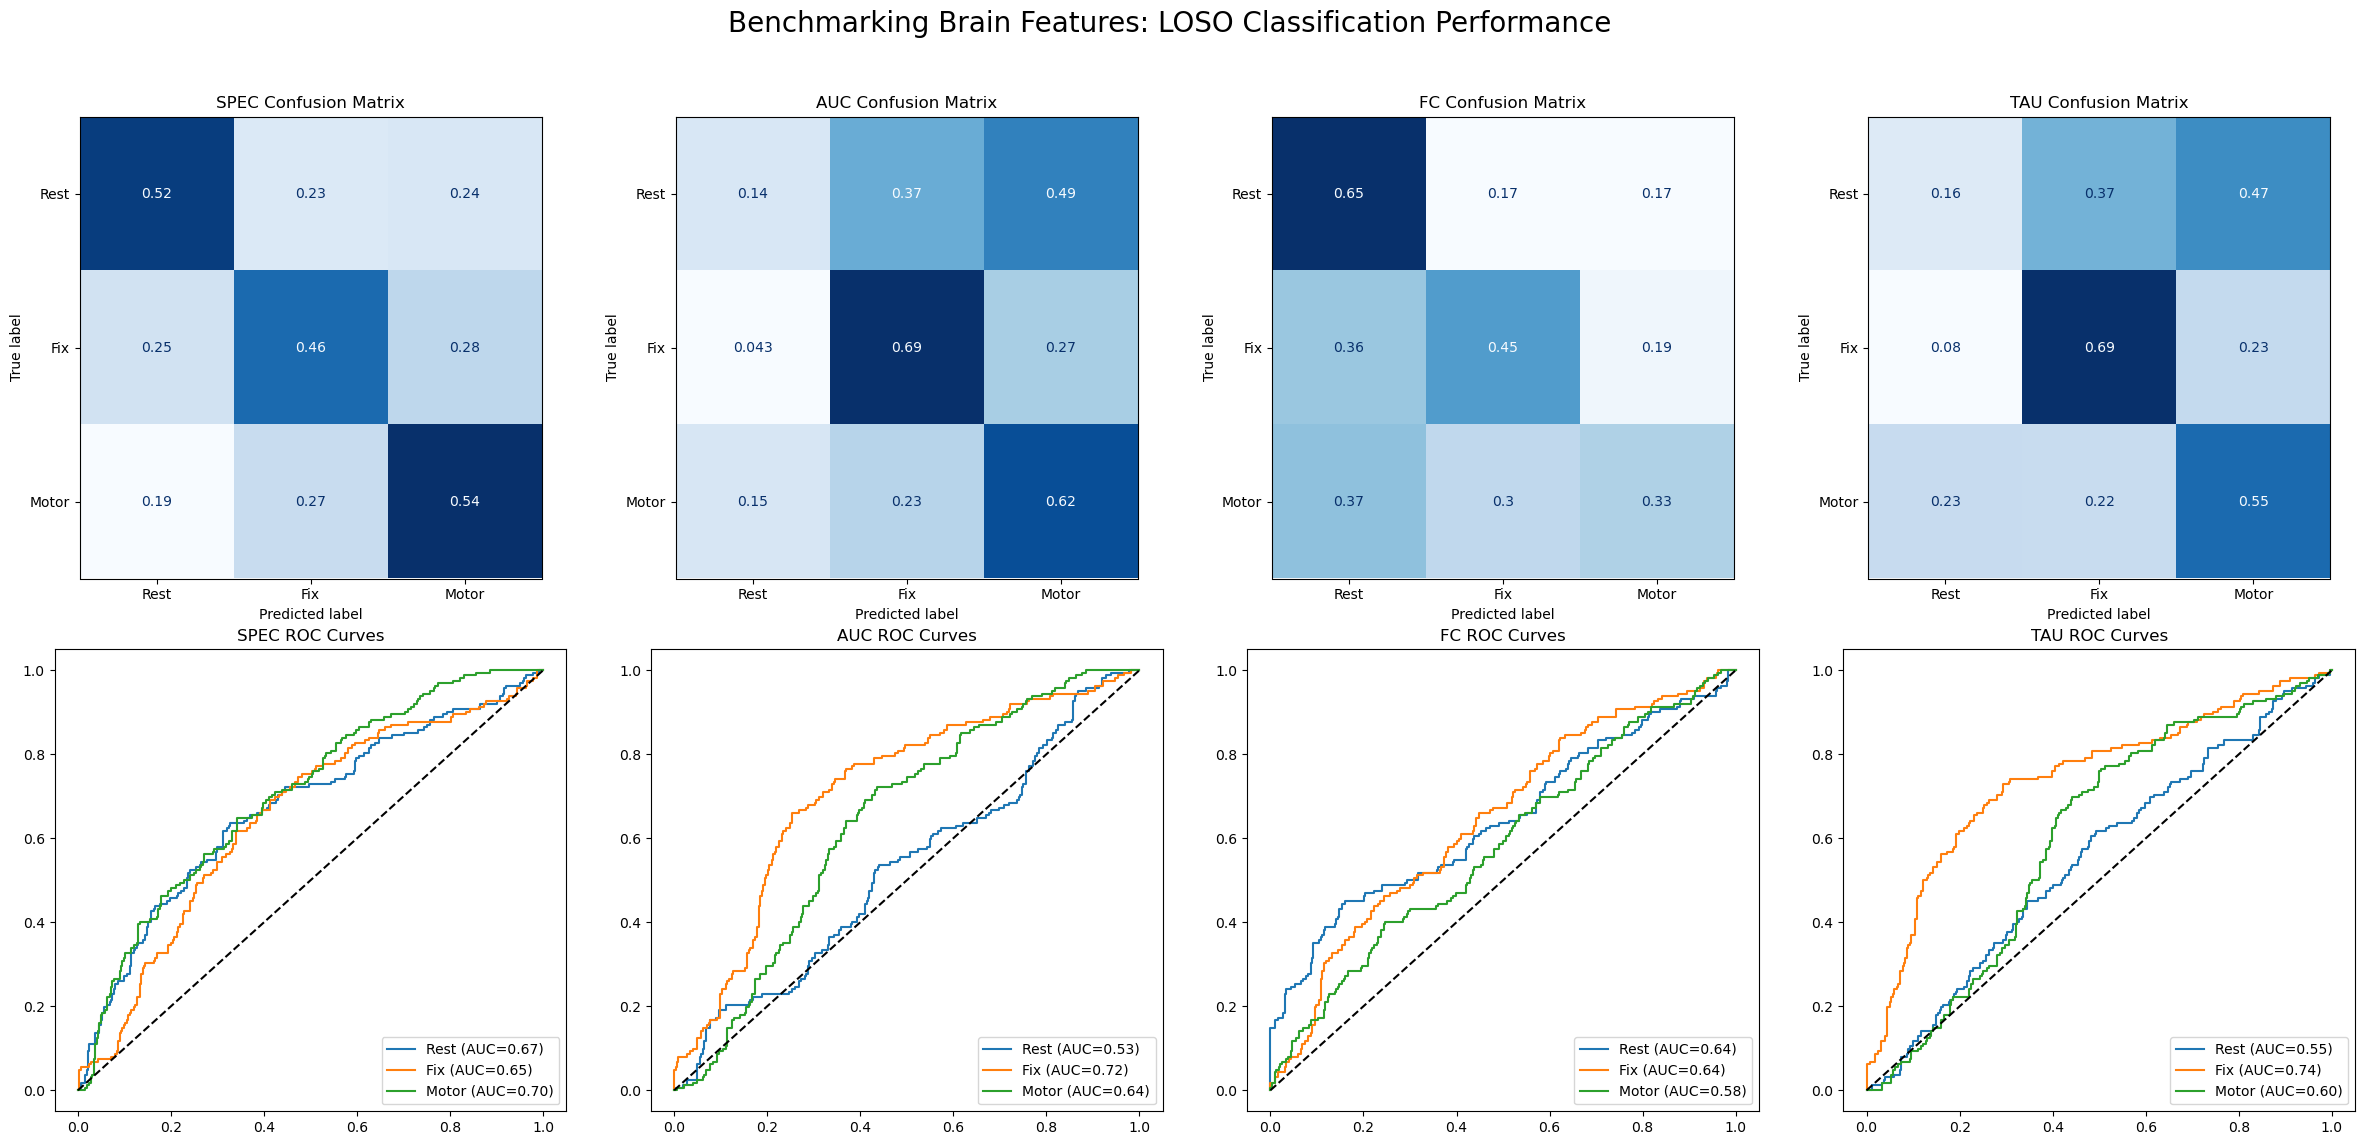

In [7]:
#  April 3, 2026: using leaving opne subject out - most recent and best results
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize

# --- 1. Load Data ---
# (Assuming files are in the current directory)
datasets_raw = {
    "SPEC": (np.load("spec_rest_all.npy"), np.load("spec_fix_all.npy"), np.load("spec_block_all.npy")),
    "AUC":  (np.load("auc_rest_all.npy"),  np.load("auc_fix_all.npy"),  np.load("auc_block_all.npy")),
    "TAU":  (np.load("tau_rest_all.npy"),  np.load("tau_fix_all.npy"),  np.load("tau_block_all.npy")),
    "FC":   (np.load("rest_all_fc.npy"),   np.load("fix_all_fc.npy"),   np.load("block_all_fc.npy"))
}

# --- 2. Helper Functions ---

def reshape_data(rest, fix, block, label):
    """Reshapes 3D or 4D arrays into (Samples, Features) and creates Groups."""
    def flatten_feat(data):
        n_sub, f1, f2, n_blk = data.shape if len(data.shape)==4 else (*data.shape, 1)
        # If FC (4D), flatten the 19x19 matrix. If 3D, just use features.
        if len(data.shape) == 4:
            return np.vstack([data[s].reshape(f1*f2, n_blk).T for s in range(n_sub)])
        else:
            return data.transpose(0, 2, 1).reshape(-1, f1)

    X_rest = flatten_feat(rest)
    X_fix = flatten_feat(fix)
    X_block = flatten_feat(block)
    
    X = np.vstack([X_rest, X_fix, X_block])
    y = np.array([0]*len(X_rest) + [1]*len(X_fix) + [2]*len(X_block))
    
    # Create Subject Groups (assuming 9 blocks per condition per subject)
    n_sub = rest.shape[0]
    n_blk = rest.shape[-1]
    groups = np.tile(np.repeat(np.arange(n_sub), n_blk), 3)
    
    return X, y, groups

def nested_group_cv(X, y, groups):
    """Performs Nested CV using GroupKFold to prevent subject leakage."""
    param_grid = {'svc__C': [0.1, 1, 10], 'svc__gamma': ['scale', 0.01]}
    
    # Outer CV: Test on unseen subjects
    outer_cv = GroupKFold(n_splits=5)
    # Inner CV: Tune on training subjects
    inner_cv = GroupKFold(n_splits=3)

    y_true, y_pred, y_proba = [], [], []

    pipeline = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel='rbf', probability=True))])

    for train_idx, test_idx in outer_cv.split(X, y, groups=groups):
        grid = GridSearchCV(pipeline, param_grid, cv=inner_cv, n_jobs=-1)
        grid.fit(X[train_idx], y[train_idx], groups=groups[train_idx])
        
        y_true.extend(y[test_idx])
        y_pred.extend(grid.predict(X[test_idx]))
        y_proba.extend(grid.predict_proba(X[test_idx]))

    return np.array(y_true), np.array(y_pred), np.array(y_proba)

# --- 3. Main Analysis Loop ---

results = {}
for label, (r, f, b) in datasets_raw.items():
    print(f"Processing Feature Set: {label}...")
    X, y, groups = reshape_data(r, f, b, label)
    y_true, y_pred, y_proba = nested_group_cv(X, y, groups)
    results[label] = (y_true, y_pred, y_proba)

# --- 4. Plotting ---

fig, axs = plt.subplots(2, 4, figsize=(24, 12))
plt.suptitle("Benchmarking Brain Features: LOSO Classification Performance", fontsize=20)

for col, label in enumerate(["SPEC", "AUC", "FC", "TAU"]):
    y_t, y_p, y_pb = results[label]
    
    # Top Row: Confusion Matrices
    cm = confusion_matrix(y_t, y_p, normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=["Rest", "Fix", "Motor"])
    disp.plot(ax=axs[0, col], cmap="Blues", colorbar=False)
    axs[0, col].set_title(f"{label} Confusion Matrix")

    # Bottom Row: ROC Curves
    y_t_bin = label_binarize(y_t, classes=[0, 1, 2])
    for i, name in enumerate(["Rest", "Fix", "Motor"]):
        fpr, tpr, _ = roc_curve(y_t_bin[:, i], y_pb[:, i])
        roc_auc = auc(fpr, tpr)
        axs[1, col].plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")
    
    axs[1, col].plot([0, 1], [0, 1], 'k--')
    axs[1, col].set_title(f"{label} ROC Curves")
    axs[1, col].legend(loc="lower right")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Running Fused Decoding (SPEC + TAU)... Total Features: 38


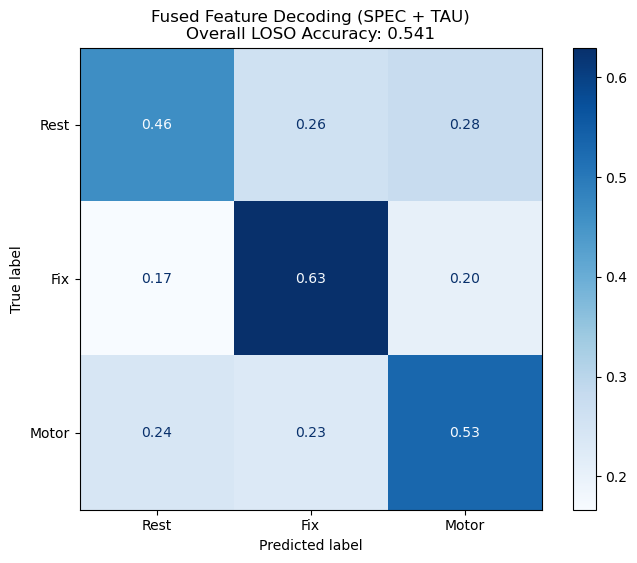

              precision    recall  f1-score   support

        Rest       0.53      0.46      0.50       162
         Fix       0.56      0.63      0.59       162
       Motor       0.52      0.53      0.53       162

    accuracy                           0.54       486
   macro avg       0.54      0.54      0.54       486
weighted avg       0.54      0.54      0.54       486



In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# --- 1. Load the Two Feature Sets ---
spec_rest = np.load("spec_rest_all.npy")
spec_fix = np.load("spec_fix_all.npy")
spec_block = np.load("spec_block_all.npy")

tau_rest = np.load("tau_rest_all.npy")
tau_fix = np.load("tau_fix_all.npy")
tau_block = np.load("tau_block_all.npy")

n_sub, n_spec_feat, n_blk = spec_rest.shape
_, n_tau_feat, _ = tau_rest.shape

# --- 2. Feature Fusion Function ---
def fuse_features(spec_data, tau_data):
    # Reshape both to (Samples, Features)
    # SPEC: (Subjects * Blocks, n_spec_features)
    X_spec = spec_data.transpose(0, 2, 1).reshape(-1, n_spec_feat)
    # TAU: (Subjects * Blocks, n_tau_features)
    X_tau = tau_data.transpose(0, 2, 1).reshape(-1, n_tau_feat)
    
    # Concatenate horizontally: (Samples, n_spec + n_tau)
    return np.hstack([X_spec, X_tau])

# Prepare the fused X and y
X_fused_rest = fuse_features(spec_rest, tau_rest)
X_fused_fix = fuse_features(spec_fix, tau_fix)
X_fused_motor = fuse_features(spec_block, tau_block)

X = np.vstack([X_fused_rest, X_fused_fix, X_fused_motor])
y = np.array([0]*len(X_fused_rest) + [1]*len(X_fused_fix) + [2]*len(X_fused_motor))

# Groups for LOSO (Subject IDs)
groups = np.tile(np.repeat(np.arange(n_sub), n_blk), 3)

# --- 3. Optimized LOSO Pipeline ---
# Using a slightly wider grid for C to handle the high-dimensional fused space
param_grid = {
    'svc__C': [0.1, 1, 10, 100], 
    'svc__gamma': ['scale', 'auto', 0.01]
}

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', class_weight='balanced', probability=True))
])

outer_cv = GroupKFold(n_splits=5)
inner_cv = GroupKFold(n_splits=3)

y_true, y_pred = [], []

print(f"Running Fused Decoding (SPEC + TAU)... Total Features: {n_spec_feat + n_tau_feat}")

for train_idx, test_idx in outer_cv.split(X, y, groups=groups):
    grid = GridSearchCV(pipe, param_grid, cv=inner_cv, n_jobs=-1)
    grid.fit(X[train_idx], y[train_idx], groups=groups[train_idx])
    
    y_true.extend(y[test_idx])
    y_pred.extend(grid.predict(X[test_idx]))

# --- 4. Results ---
acc = np.mean(np.array(y_true) == np.array(y_pred))
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm_norm, display_labels=["Rest", "Fix", "Motor"])
disp.plot(cmap="Blues", ax=ax, values_format=".2f")
ax.set_title(f"Fused Feature Decoding (SPEC + TAU)\nOverall LOSO Accuracy: {acc:.3f}")
plt.show()

print(classification_report(y_true, y_pred, target_names=["Rest", "Fix", "Motor"]))

Processing Feature Set: SPEC...
Processing Feature Set: AUC...
Processing Feature Set: TAU...
Processing Feature Set: FC...


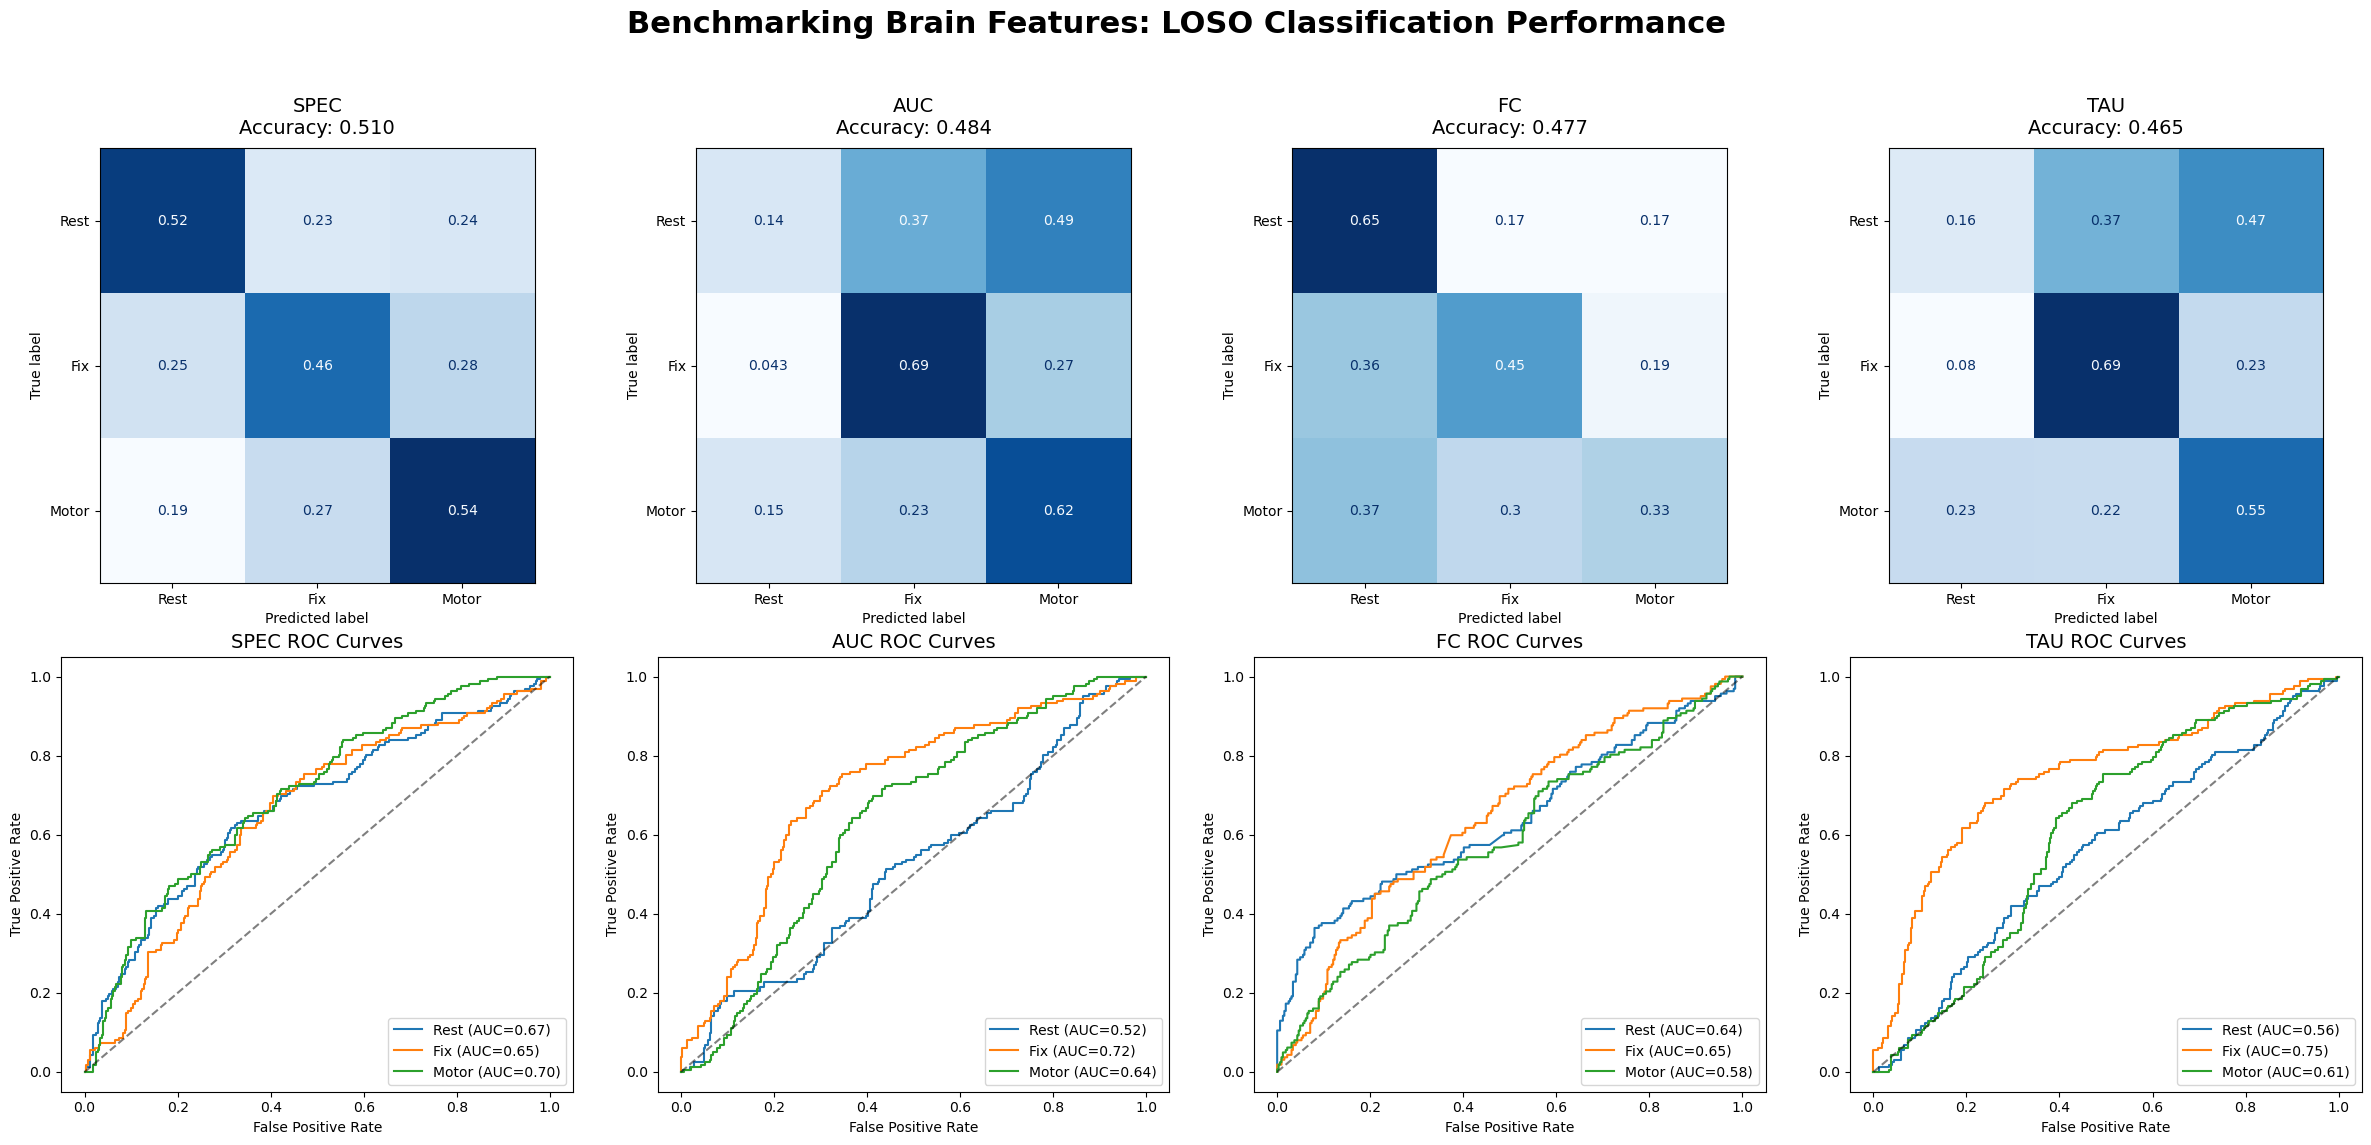

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import label_binarize

# --- 1. Load Data ---
datasets_raw = {
    "SPEC": (np.load("spec_rest_all.npy"), np.load("spec_fix_all.npy"), np.load("spec_block_all.npy")),
    "AUC":  (np.load("auc_rest_all.npy"),  np.load("auc_fix_all.npy"),  np.load("auc_block_all.npy")),
    "TAU":  (np.load("tau_rest_all.npy"),  np.load("tau_fix_all.npy"),  np.load("tau_block_all.npy")),
    "FC":   (np.load("rest_all_fc.npy"),   np.load("fix_all_fc.npy"),   np.load("block_all_fc.npy"))
}

# --- 2. Helper Functions ---

def reshape_data(rest, fix, block, label):
    def flatten_feat(data):
        n_sub, f1, f2, n_blk = data.shape if len(data.shape)==4 else (*data.shape, 1)
        if len(data.shape) == 4:
            return np.vstack([data[s].reshape(f1*f2, n_blk).T for s in range(n_sub)])
        else:
            return data.transpose(0, 2, 1).reshape(-1, f1)

    X_rest = flatten_feat(rest)
    X_fix = flatten_feat(fix)
    X_block = flatten_feat(block)
    
    X = np.vstack([X_rest, X_fix, X_block])
    y = np.array([0]*len(X_rest) + [1]*len(X_fix) + [2]*len(X_block))
    
    n_sub = rest.shape[0]
    n_blk = rest.shape[-1]
    groups = np.tile(np.repeat(np.arange(n_sub), n_blk), 3)
    
    return X, y, groups

def nested_group_cv(X, y, groups):
    param_grid = {'svc__C': [0.1, 1, 10], 'svc__gamma': ['scale', 0.01]}
    outer_cv = GroupKFold(n_splits=5)
    inner_cv = GroupKFold(n_splits=3)

    y_true, y_pred, y_proba = [], [], []
    pipeline = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel='rbf', probability=True))])

    for train_idx, test_idx in outer_cv.split(X, y, groups=groups):
        grid = GridSearchCV(pipeline, param_grid, cv=inner_cv, n_jobs=-1)
        grid.fit(X[train_idx], y[train_idx], groups=groups[train_idx])
        
        y_true.extend(y[test_idx])
        y_pred.extend(grid.predict(X[test_idx]))
        y_proba.extend(grid.predict_proba(X[test_idx]))

    return np.array(y_true), np.array(y_pred), np.array(y_proba)

# --- 3. Main Analysis Loop ---

results = {}
for label, (r, f, b) in datasets_raw.items():
    print(f"Processing Feature Set: {label}...")
    X, y, groups = reshape_data(r, f, b, label)
    y_true, y_pred, y_proba = nested_group_cv(X, y, groups)
    results[label] = (y_true, y_pred, y_proba)

# --- 4. Plotting ---

fig, axs = plt.subplots(2, 4, figsize=(24, 12))
plt.suptitle("Benchmarking Brain Features: LOSO Classification Performance", fontsize=22, fontweight='bold')

for col, label in enumerate(["SPEC", "AUC", "FC", "TAU"]):
    y_t, y_p, y_pb = results[label]
    
    # Calculate Overall Accuracy for this feature set
    acc = accuracy_score(y_t, y_p)
    
    # Top Row: Confusion Matrices
    cm = confusion_matrix(y_t, y_p, normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=["Rest", "Fix", "Motor"])
    disp.plot(ax=axs[0, col], cmap="Blues", colorbar=False)
    
    # --- UPDATED TITLE ---
    axs[0, col].set_title(f"{label}\nAccuracy: {acc:.3f}", fontsize=14, pad=10)
    axs[0, col].set_xlabel("Predicted label")
    axs[0, col].set_ylabel("True label")

    # Bottom Row: ROC Curves
    y_t_bin = label_binarize(y_t, classes=[0, 1, 2])
    for i, name in enumerate(["Rest", "Fix", "Motor"]):
        fpr, tpr, _ = roc_curve(y_t_bin[:, i], y_pb[:, i])
        roc_auc = auc(fpr, tpr)
        axs[1, col].plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")
    
    axs[1, col].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axs[1, col].set_title(f"{label} ROC Curves", fontsize=14)
    axs[1, col].set_xlabel("False Positive Rate")
    axs[1, col].set_ylabel("True Positive Rate")
    axs[1, col].legend(loc="lower right")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()